## Capstone Project of RML (Group 4) - HMDA dataset


### Step 0: Google Drive Setup & Install Libraries

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install required libraries
!pip install duckdb lightgbm solas-ai-disparity -q
print("All libraries installed.")

ERROR: Could not find a version that satisfies the requirement solas-ai-disparity (from versions: none)
ERROR: No matching distribution found for solas-ai-disparity
All libraries installed.


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/2024_lar.zip"

if not os.path.exists("/content/2024_lar.txt"):
    print("Unzipping... this will take 2-3 minutes")
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall("/content/")
    print("Unzip done!")
else:
    print("File already unzipped — skipping.")

Unzipping... this will take 2-3 minutes
Unzip done!


### Pre-modeling

#### 1. Data Inspection

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import duckdb

In [6]:
print("Loading data with DuckDB...")

conn = duckdb.connect()
raw_data = conn.execute("""
    SELECT *
    FROM read_csv(
        '/content/2024_lar.txt',
        delim='|',
        header=true,
        sample_size=-1,
        ignore_errors=true
    )
""").df()

print(f"Successfully loaded! Shape: {raw_data.shape}")
print(f"RAM used: {raw_data.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Loading data with DuckDB...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Successfully loaded! Shape: (12259119, 99)
RAM used: 27.39 GB


In [7]:
raw_data.shape[0]

12259119

In [8]:
raw_data.head(10)

,activity_year,lei,derived_msa_md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,denial_reason_2,denial_reason_3,denial_reason_4,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units
0,2024,549300CLRXFVF83ZL806,35614,NJ,34017,34017017100,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Hispanic or Latino,...,<NA>,<NA>,<NA>,5359,91.23,101900,62.0,465,1608,0
1,2024,549300CLRXFVF83ZL806,99999,VA,51033,51033030501,C,VA:First Lien,Single Family (1-4 Units):Site-Built,Hispanic or Latino,...,<NA>,<NA>,<NA>,4648,38.06,73900,172.0,1277,1513,18
2,2024,549300CLRXFVF83ZL806,35004,NY,36059,36059405900,C,FHA:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,<NA>,<NA>,<NA>,5395,31.36,156200,117.0,1513,1600,66
3,2024,549300CLRXFVF83ZL806,33124,FL,12086,12086001004,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Hispanic or Latino,...,<NA>,<NA>,<NA>,7409,97.99,79400,57.0,443,1726,28
4,2024,549300CLRXFVF83ZL806,35084,NJ,34013,34013000600,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Hispanic or Latino,...,<NA>,<NA>,<NA>,4295,91.13,133300,47.0,499,1395,70
5,2024,549300CLRXFVF83ZL806,35004,NY,36103,36103159109,C,FHA:First Lien,Single Family (1-4 Units):Site-Built,Hispanic or Latino,...,<NA>,<NA>,<NA>,2902,41.21,156200,52.0,908,1069,64
6,2024,549300CLRXFVF83ZL806,99999,NY,36105,36105952500,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,<NA>,<NA>,<NA>,2243,17.79,83800,152.0,723,1588,43
7,2024,549300CLRXFVF83ZL806,15980,FL,12071,12071040212,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,<NA>,<NA>,<NA>,6353,64.79,88800,78.0,1315,1873,17
8,2024,549300CLRXFVF83ZL806,35004,NY,36059,36059414501,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Hispanic or Latino,...,<NA>,<NA>,<NA>,5626,66.53,156200,105.0,1849,1746,63
9,2024,549300CLRXFVF83ZL806,35614,NY,36081,36081050000,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,<NA>,<NA>,<NA>,4778,96.53,101900,70.0,139,583,64


In [9]:
list(raw_data.columns)

['activity_year',
 'lei',
 'derived_msa_md',
 'state_code',
 'county_code',
 'census_tract',
 'conforming_loan_limit',
 'derived_loan_product_type',
 'derived_dwelling_category',
 'derived_ethnicity',
 'derived_race',
 'derived_sex',
 'action_taken',
 'purchaser_type',
 'preapproval',
 'loan_type',
 'loan_purpose',
 'lien_status',
 'reverse_mortgage',
 'open_end_line_of_credit',
 'business_or_commercial_purpose',
 'loan_amount',
 'combined_loan_to_value_ratio',
 'interest_rate',
 'rate_spread',
 'hoepa_status',
 'total_loan_costs',
 'total_points_and_fees',
 'origination_charges',
 'discount_points',
 'lender_credits',
 'loan_term',
 'prepayment_penalty_term',
 'intro_rate_period',
 'negative_amortization',
 'interest_only_payment',
 'balloon_payment',
 'other_nonamortizing_features',
 'property_value',
 'construction_method',
 'occupancy_type',
 'manufactured_home_secured_property_type',
 'manufactured_home_land_property_interest',
 'total_units',
 'multifamily_affordable_units',
 'in

In [10]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12259119 entries, 0 to 12259118
Data columns (total 99 columns):
 #   Column                                    Dtype  
---  ------                                    -----  
 0   activity_year                             int64  
 1   lei                                       object 
 2   derived_msa_md                            int64  
 3   state_code                                object 
 4   county_code                               object 
 5   census_tract                              object 
 6   conforming_loan_limit                     object 
 7   derived_loan_product_type                 object 
 8   derived_dwelling_category                 object 
 9   derived_ethnicity                         object 
 10  derived_race                              object 
 11  derived_sex                               object 
 12  action_taken                              int64  
 13  purchaser_type                            int64  
 14  

#### 2. Target Construction

We construct a binary target variable based on the `action_taken` field, where approved applications (values 1 and 2) are labeled as 1, and denied applications (value 3) are labeled as 0. All other categories are excluded to ensure a clean binary classification setup.

In [11]:
import numpy as np

# Create a copy of the original dataset to avoid modifying raw data
df = raw_data.copy()

# Step 1: Filter the dataset to keep only relevant action_taken values
# Keep:
# 1 = Loan originated
# 2 = Approved but not accepted
# 3 = Denied
# Remove all other categories (e.g., withdrawn, incomplete, etc.)
df["action_taken"] = pd.to_numeric(df["action_taken"], errors="coerce")
df = df[df["action_taken"].isin([1, 2, 3])]

# Step 2: Create a binary target variable
# Approved (1, 2) → 1
# Denied (3) → 0
df["target"] = np.where(
    df["action_taken"].isin([1, 2]),
    1,
    0
)

# Step 3: Check the distribution of the target variable
print(df["target"].value_counts())
print(df["target"].value_counts(normalize=True))

target
1    6558285
0    2103463
Name: count, dtype: int64
target
1    0.757155
0    0.242845
Name: proportion, dtype: float64


#### 3. Data Cleaning

In [12]:
df = df.replace(["NA", "Exempt"], np.nan)

In [13]:
# Identifying Missing Values
missing = df.isna().mean().sort_values(ascending=False)
missing.head(20)

,0
co_applicant_ethnicity_5,0.999996
co_applicant_ethnicity_4,0.999988
applicant_ethnicity_5,0.999988
applicant_ethnicity_4,0.999960
co_applicant_race_5,0.999913
applicant_race_5,0.999785
co_applicant_race_4,0.999763
co_applicant_ethnicity_3,0.999541
applicant_race_4,0.999362
applicant_ethnicity_3,0.998645


In [14]:
# Dropping Columns with More Than 90% Missing Values
cols_to_drop = missing[missing > 0.9].index
df = df.drop(columns=cols_to_drop)
print(f"Dropped {len(cols_to_drop)} columns. Remaining: {df.shape[1]}")

Dropped 26 columns. Remaining: 74


In [15]:
# Convert numeric variables
df["income"]       = pd.to_numeric(df["income"],       errors="coerce")
df["loan_amount"]  = pd.to_numeric(df["loan_amount"],  errors="coerce")

# Convert categorical variables
cat_cols = ["derived_race", "derived_ethnicity", "derived_sex"]
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype("category")

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8661748 entries, 0 to 12259118
Data columns (total 74 columns):
 #   Column                                    Dtype   
---  ------                                    -----   
 0   activity_year                             int64   
 1   lei                                       object  
 2   derived_msa_md                            int64   
 3   state_code                                object  
 4   county_code                               object  
 5   census_tract                              object  
 6   conforming_loan_limit                     object  
 7   derived_loan_product_type                 object  
 8   derived_dwelling_category                 object  
 9   derived_ethnicity                         category
 10  derived_race                              category
 11  derived_sex                               category
 12  action_taken                              int64   
 13  purchaser_type                            int6

#### 4. Baseline Fairness Analysis (Pre-Model)

Before building the model, we examine fairness in the raw data by comparing approval rates across different demographic groups.

In [17]:
df.groupby("derived_race")["target"].mean().sort_values()

,target
derived_race,
Free Form Text Only,0.410526
Native Hawaiian or Other Pacific Islander,0.613013
2 or more minority races,0.619721
American Indian or Alaska Native,0.629659
Black or African American,0.633430
Race Not Available,0.722381
White,0.781921
Asian,0.787291
Joint,0.804574


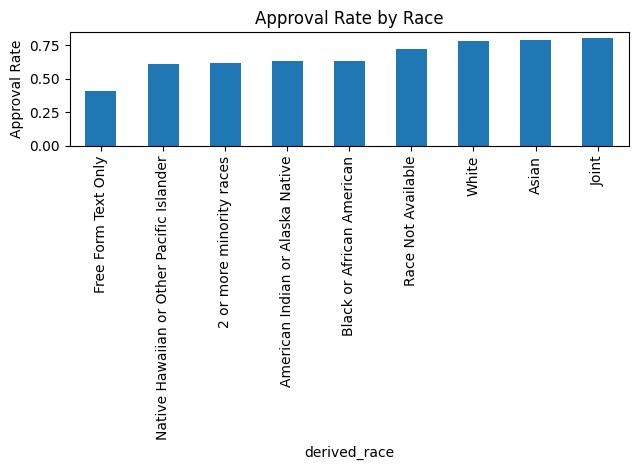

In [18]:
df.groupby("derived_race")["target"].mean().sort_values().plot(kind="bar")
plt.ylabel("Approval Rate")
plt.title("Approval Rate by Race")
plt.tight_layout()
plt.show()

In [19]:
df.groupby("derived_ethnicity")["target"].mean()

,target
derived_ethnicity,
Ethnicity Not Available,0.729368
Free Form Text Only,0.514610
Hispanic or Latino,0.695343
Joint,0.792610
Not Hispanic or Latino,0.773475


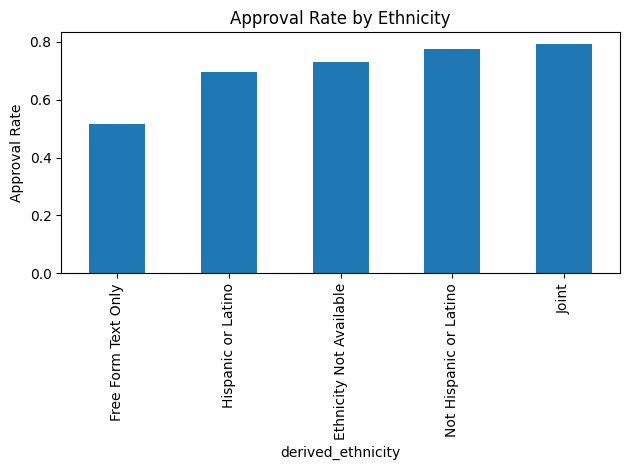

In [20]:
df.groupby("derived_ethnicity")["target"].mean().sort_values().plot(kind="bar")
plt.ylabel("Approval Rate")
plt.title("Approval Rate by Ethnicity")
plt.tight_layout()
plt.show()

In [21]:
df.groupby("derived_sex")["target"].mean()

,target
derived_sex,
Female,0.707111
Joint,0.816699
Male,0.735658
Sex Not Available,0.733773


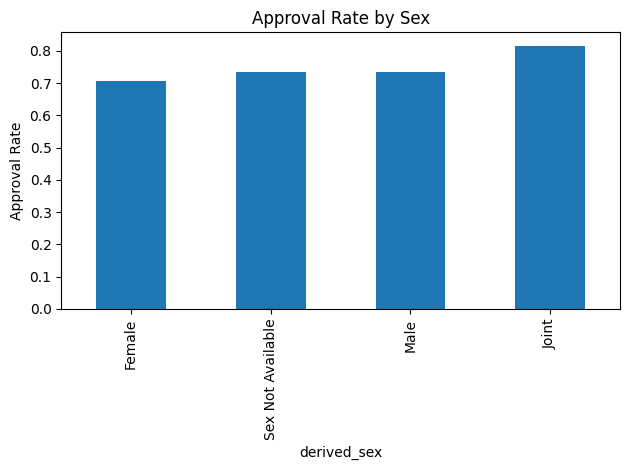

In [22]:
df.groupby("derived_sex")["target"].mean().sort_values().plot(kind="bar")
plt.ylabel("Approval Rate")
plt.title("Approval Rate by Sex")
plt.tight_layout()
plt.show()

In [23]:
df.groupby("derived_race").agg({
    "income": "mean",
    "target": "mean"
})

,income,target
derived_race,,
2 or more minority races,2478.580259,0.619721
American Indian or Alaska Native,189.579381,0.629659
Asian,223.782925,0.787291
Black or African American,312.504156,0.633430
Free Form Text Only,117.999535,0.410526
Joint,186.673286,0.804574
Native Hawaiian or Other Pacific Islander,136.327801,0.613013
Race Not Available,169.927337,0.722381
White,163.145376,0.781921


**Comparing Approval Rates and Income Across Racial Groups**

The results show clear differences in approval rates across racial groups. For example, White and Asian applicants have relatively high approval rates (around 78–79%), while Black or African American applicants have a lower approval rate (around 63%). Interestingly, these differences are not fully explained by income levels.

#### DTI Processing

The original `debt_to_income_ratio` variable contains a mixture of formats. We convert to numeric then simplify into groups.

In [24]:
def dti_to_numeric(x):
    if pd.isna(x):
        return np.nan
    x = str(x)
    if "<20%" in x:        return 15
    elif "20%-<30%" in x:  return 25
    elif "30%-<36%" in x:  return 33
    elif "36" in x and "%" in x: return 36
    elif "50%-60%" in x:   return 55
    elif ">60%" in x:      return 65
    try:
        return float(x)
    except:
        return np.nan

def simplify_dti(x):
    if pd.isna(x): return "Missing"
    if x < 30:     return "<30%"
    elif x < 40:   return "30-40%"
    elif x < 50:   return "40-50%"
    elif x < 60:   return "50-60%"
    else:          return ">60%"

df["dti_numeric"] = df["debt_to_income_ratio"].apply(dti_to_numeric)
df["dti_group"]   = df["dti_numeric"].apply(simplify_dti)
print("DTI processing done.")

DTI processing done.


In [25]:
result = df.groupby(["derived_race", "dti_group"])["target"].mean().unstack()
result["overall_approval_rate"] = df.groupby("derived_race")["target"].mean()
result

dti_group,30-40%,40-50%,50-60%,<30%,>60%,Missing,overall_approval_rate
derived_race,,,,,,,
2 or more minority races,0.771525,0.795628,0.563624,0.558792,0.054297,0.582692,0.619721
American Indian or Alaska Native,0.767349,0.794302,0.556998,0.592345,0.046657,0.612577,0.629659
Asian,0.901438,0.895853,0.543929,0.841224,0.060949,0.756799,0.787291
Black or African American,0.755349,0.782178,0.590037,0.594256,0.056617,0.636871,0.633430
Free Form Text Only,0.628895,0.711221,0.350365,0.447183,0.008532,0.195122,0.410526
Joint,0.879516,0.878217,0.692835,0.835759,0.138678,0.756180,0.804574
Native Hawaiian or Other Pacific Islander,0.771999,0.786864,0.591261,0.604984,0.056678,0.600861,0.613013
Race Not Available,0.831719,0.827933,0.587694,0.759695,0.075564,0.728184,0.722381
White,0.874311,0.867662,0.628879,0.826859,0.096398,0.751133,0.781921


### Modeling

#### 5. Feature Selection

In [26]:
from sklearn.model_selection import train_test_split

# Features without race
featuresA = [
    "income",
    "dti_group",
    "loan_term",
    "loan_type",
    "loan_purpose",
    "applicant_credit_score_type",
    "tract_minority_population_percent",
    "combined_loan_to_value_ratio",
    "property_value"
]

# Features with race
featuresB = featuresA + ["derived_race"]
target    = "target"

print(f"Model A features: {len(featuresA)}")
print(f"Model B features: {len(featuresB)}")

Model A features: 9
Model B features: 10


#### 6. Train-Test Split

In [27]:
# Define feature types
numeric_features_A = [
    "income",
    "tract_minority_population_percent",
    "combined_loan_to_value_ratio",
    "property_value"
]

categorical_features_A = [
    "dti_group",
    "loan_term",
    "loan_type",
    "loan_purpose",
    "applicant_credit_score_type"
]

# Clean dtypes
for col in numeric_features_A:
    df[col] = pd.to_numeric(df[col], errors="coerce")

for col in categorical_features_A:
    df[col] = df[col].astype("string")

df["derived_race"] = df["derived_race"].astype("string")

# Build X and y
X_A = df[featuresA].copy()
y   = df[target].astype(int).copy()

# Train/test split
X_train_A, X_test_A, y_train, y_test = train_test_split(
    X_A, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

n_train   = len(X_train_A)
n_test    = len(X_test_A)
pct_train = 100 * n_train / len(X_A)
pct_test  = 100 * n_test  / len(X_A)

print(X_train_A.dtypes)
print(f"\nModel A → Train: {X_train_A.shape} ({n_train:,} rows, {pct_train:.1f}%), "
      f"Test: {X_test_A.shape} ({n_test:,} rows, {pct_test:.1f}%)")

income                                      float64
dti_group                            string[python]
loan_term                            string[python]
loan_type                            string[python]
loan_purpose                         string[python]
applicant_credit_score_type          string[python]
tract_minority_population_percent           float64
combined_loan_to_value_ratio                float64
property_value                              float64
dtype: object

Model A → Train: (6929398, 9) (6,929,398 rows, 80.0%), Test: (1732350, 9) (1,732,350 rows, 20.0%)


In [28]:
# Build X for Model B using same split indices
X_B = df[featuresB].copy()

X_train_B = X_B.loc[X_train_A.index].copy()
X_test_B  = X_B.loc[X_test_A.index].copy()

numeric_features_B    = numeric_features_A.copy()
categorical_features_B = categorical_features_A + ["derived_race"]

for col in numeric_features_B:
    X_train_B[col] = pd.to_numeric(X_train_B[col], errors="coerce")
    X_test_B[col]  = pd.to_numeric(X_test_B[col],  errors="coerce")

for col in categorical_features_B:
    X_train_B[col] = X_train_B[col].astype("string")
    X_test_B[col]  = X_test_B[col].astype("string")

print(X_train_B.dtypes)
print(f"\nModel B → Train: {X_train_B.shape}, Test: {X_test_B.shape}")

income                                      float64
dti_group                            string[python]
loan_term                            string[python]
loan_type                            string[python]
loan_purpose                         string[python]
applicant_credit_score_type          string[python]
tract_minority_population_percent           float64
combined_loan_to_value_ratio                float64
property_value                              float64
derived_race                         string[python]
dtype: object

Model B → Train: (6929398, 10), Test: (1732350, 10)


#### 7. Logistic Regression (Model A vs Model B)

**Model A**

In [30]:
import numpy as np
import pandas as pd

def fix_dataframe_for_lgbm(df):
    df = df.copy()
    for col in df.columns:
        if df[col].dtype in ["string", "object", "category"]:
            df[col] = df[col].astype(str)
            df[col] = df[col].replace("nan", np.nan)
            df[col] = df[col].replace("<NA>", np.nan)
        else:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

X_train_A = fix_dataframe_for_lgbm(X_train_A)
X_test_A  = fix_dataframe_for_lgbm(X_test_A)
X_train_B = fix_dataframe_for_lgbm(X_train_B)
X_test_B  = fix_dataframe_for_lgbm(X_test_B)

print("✅ All dataframes fixed!")
print(f"X_train_A dtypes:\n{X_train_A.dtypes}")

✅ All dataframes fixed!
X_train_A dtypes:
income                               float64
dti_group                             object
loan_term                             object
loan_type                             object
loan_purpose                          object
applicant_credit_score_type           object
tract_minority_population_percent    float64
combined_loan_to_value_ratio         float64
property_value                       float64
dtype: object


In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Preprocessing for Model A
numeric_transformer_A = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])
categorical_transformer_A = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore"))
])
preprocessor_A = ColumnTransformer(transformers=[
    ("num", numeric_transformer_A,    numeric_features_A),
    ("cat", categorical_transformer_A, categorical_features_A)
])

# Model A pipeline
model_A = Pipeline(steps=[
    ("preprocessor", preprocessor_A),
    ("classifier",   LogisticRegression(max_iter=1000, n_jobs=-1))
])

model_A.fit(X_train_A, y_train)

y_train_pred_A = model_A.predict(X_train_A)
y_test_pred_A  = model_A.predict(X_test_A)

train_acc_A = accuracy_score(y_train, y_train_pred_A)
test_acc_A  = accuracy_score(y_test,  y_test_pred_A)

print("========== Model A: Logistic Regression ==========")
print(f"Train Accuracy: {train_acc_A:.4f}")
print(f"Test Accuracy:  {test_acc_A:.4f}")

========== Model A: Logistic Regression ==========
Train Accuracy: 0.8262
Test Accuracy:  0.8258


In [32]:
# Fairness metrics for Model A LR
pred_A   = model_A.predict(X_test_A)
result_A = X_test_A.copy()
result_A["y_true"] = y_test.values
result_A["y_pred"] = pred_A
result_A["race"]   = df.loc[X_test_A.index, "derived_race"].astype("string")

def compute_metrics(group):
    tn, fp, fn, tp = confusion_matrix(
        group["y_true"], group["y_pred"], labels=[0, 1]
    ).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    acc = (tp + tn) / (tp + tn + fp + fn)
    return pd.Series({
        "Count":         len(group),
        "Approval_Rate": group["y_pred"].mean(),
        "FPR":           fpr,
        "FNR":           fnr,
        "Accuracy":      acc
    })

fairness_A = result_A.groupby("race", dropna=False).apply(compute_metrics)
fairness_A.round(4)

,Count,Approval_Rate,FPR,FNR,Accuracy
race,,,,,
2 or more minority races,4312.0,0.7948,0.5363,0.0447,0.7669
American Indian or Alaska Native,12613.0,0.8237,0.5864,0.0379,0.7600
Asian,104809.0,0.8784,0.5315,0.0276,0.8650
Black or African American,152205.0,0.8152,0.5829,0.0494,0.7542
Free Form Text Only,442.0,0.6244,0.4157,0.0571,0.7262
Joint,37823.0,0.9078,0.6588,0.0310,0.8451
Native Hawaiian or Other Pacific Islander,4239.0,0.7726,0.5110,0.0562,0.7639
Race Not Available,305341.0,0.8544,0.6013,0.0483,0.7982
White,1110566.0,0.8919,0.6191,0.0321,0.8401


**Model B**

In [33]:
# Preprocessing for Model B
numeric_transformer_B = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])
categorical_transformer_B = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore"))
])
preprocessor_B = ColumnTransformer(transformers=[
    ("num", numeric_transformer_B,    numeric_features_B),
    ("cat", categorical_transformer_B, categorical_features_B)
])

# Model B pipeline
model_B = Pipeline(steps=[
    ("preprocessor", preprocessor_B),
    ("classifier",   LogisticRegression(max_iter=1000, n_jobs=-1))
])

model_B.fit(X_train_B, y_train)

y_train_pred_B = model_B.predict(X_train_B)
y_test_pred_B  = model_B.predict(X_test_B)

train_acc_B = accuracy_score(y_train, y_train_pred_B)
test_acc_B  = accuracy_score(y_test,  y_test_pred_B)

print("========== Model B: Logistic Regression (+ race) ==========")
print(f"Train Accuracy: {train_acc_B:.4f}")
print(f"Test Accuracy:  {test_acc_B:.4f}")

========== Model B: Logistic Regression (+ race) ==========
Train Accuracy: 0.8279
Test Accuracy:  0.8276


In [34]:
# Fairness metrics for Model B LR
pred_B   = model_B.predict(X_test_B)
result_B = X_test_B.copy()
result_B["y_true"] = y_test.values
result_B["y_pred"] = pred_B
result_B["race"]   = df.loc[X_test_B.index, "derived_race"].astype("string")

fairness_B = result_B.groupby("race", dropna=False).apply(compute_metrics)
fairness_B.round(4)

,Count,Approval_Rate,FPR,FNR,Accuracy
race,,,,,
2 or more minority races,4312.0,0.7324,0.4346,0.0827,0.7825
American Indian or Alaska Native,12613.0,0.7560,0.4782,0.0820,0.7721
Asian,104809.0,0.8867,0.5480,0.0215,0.8662
Black or African American,152205.0,0.7681,0.5088,0.0808,0.7617
Free Form Text Only,442.0,0.4638,0.2772,0.2514,0.7330
Joint,37823.0,0.9185,0.6838,0.0238,0.8459
Native Hawaiian or Other Pacific Islander,4239.0,0.7320,0.4496,0.0831,0.7719
Race Not Available,305341.0,0.8389,0.5704,0.0579,0.7999
White,1110566.0,0.9046,0.6460,0.0234,0.8410


**Comparison of Accuracy, FNR, FPR between Model A (without race) and Model B (with race)**

In [35]:
fairness_A_renamed = fairness_A.rename(columns={
    "FPR": "FPR_A", "FNR": "FNR_A",
    "Accuracy": "Accuracy_A", "Approval_Rate": "Approval_Rate_A"
}).drop(columns=["Count"])

fairness_B_renamed = fairness_B.rename(columns={
    "FPR": "FPR_B", "FNR": "FNR_B",
    "Accuracy": "Accuracy_B", "Approval_Rate": "Approval_Rate_B"
}).drop(columns=["Count"])

comparison_lr = fairness_A_renamed.join(fairness_B_renamed)
comparison_lr.round(4)

,Approval_Rate_A,FPR_A,FNR_A,Accuracy_A,Approval_Rate_B,FPR_B,FNR_B,Accuracy_B
race,,,,,,,,
2 or more minority races,0.7948,0.5363,0.0447,0.7669,0.7324,0.4346,0.0827,0.7825
American Indian or Alaska Native,0.8237,0.5864,0.0379,0.7600,0.7560,0.4782,0.0820,0.7721
Asian,0.8784,0.5315,0.0276,0.8650,0.8867,0.5480,0.0215,0.8662
Black or African American,0.8152,0.5829,0.0494,0.7542,0.7681,0.5088,0.0808,0.7617
Free Form Text Only,0.6244,0.4157,0.0571,0.7262,0.4638,0.2772,0.2514,0.7330
Joint,0.9078,0.6588,0.0310,0.8451,0.9185,0.6838,0.0238,0.8459
Native Hawaiian or Other Pacific Islander,0.7726,0.5110,0.0562,0.7639,0.7320,0.4496,0.0831,0.7719
Race Not Available,0.8544,0.6013,0.0483,0.7982,0.8389,0.5704,0.0579,0.7999
White,0.8919,0.6191,0.0321,0.8401,0.9046,0.6460,0.0234,0.8410


In [36]:
print("========== Model A: Logistic Regression ==========")
print(f"Train Accuracy: {train_acc_A:.4f}")
print(f"Test Accuracy:  {test_acc_A:.4f}")
print("========== Model B: Logistic Regression (+ race) ==========")
print(f"Train Accuracy: {train_acc_B:.4f}")
print(f"Test Accuracy:  {test_acc_B:.4f}")

========== Model A: Logistic Regression ==========
Train Accuracy: 0.8262
Test Accuracy:  0.8258
========== Model B: Logistic Regression (+ race) ==========
Train Accuracy: 0.8279
Test Accuracy:  0.8276


#### 8. Gradient Boosted Tree — LightGBM (Model A vs Model B)

**Model A**

In [37]:
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# LightGBM Model A pipeline
model_A_gbt = Pipeline(steps=[
    ("preprocessor", preprocessor_A),
    ("classifier", LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])

model_A_gbt.fit(X_train_A, y_train)

y_train_pred_gbt = model_A_gbt.predict(X_train_A)
y_test_pred_gbt  = model_A_gbt.predict(X_test_A)

train_acc_gbt = accuracy_score(y_train, y_train_pred_gbt)
test_acc_gbt  = accuracy_score(y_test,  y_test_pred_gbt)

print("========== Model A: Gradient Boosting (LightGBM) ==========")
print(f"Train Accuracy: {train_acc_gbt:.4f}")
print(f"Test Accuracy:  {test_acc_gbt:.4f}")

========== Model A: Gradient Boosting (LightGBM) ==========
Train Accuracy: 0.8473
Test Accuracy:  0.8472


In [38]:
# Fairness metrics for Model A GBT
pred_gbt   = model_A_gbt.predict(X_test_A)
result_gbt = X_test_A.copy()
result_gbt["y_true"] = y_test.values
result_gbt["y_pred"] = pred_gbt
result_gbt["race"]   = df.loc[X_test_A.index, "derived_race"].astype("string")

fairness_gbt = result_gbt.groupby("race", dropna=False).apply(compute_metrics)
fairness_gbt.round(4)

,Count,Approval_Rate,FPR,FNR,Accuracy
race,,,,,
2 or more minority races,4312.0,0.7688,0.4582,0.0383,0.8008
American Indian or Alaska Native,12613.0,0.7786,0.4698,0.0413,0.8008
Asian,104809.0,0.8781,0.5048,0.0207,0.8761
Black or African American,152205.0,0.7853,0.4965,0.0465,0.7879
Free Form Text Only,442.0,0.6063,0.3933,0.0686,0.7353
Joint,37823.0,0.9015,0.5824,0.0200,0.8690
Native Hawaiian or Other Pacific Islander,4239.0,0.7573,0.4592,0.0476,0.7896
Race Not Available,305341.0,0.8562,0.5567,0.0288,0.8247
White,1110566.0,0.8791,0.5461,0.0282,0.8590


**Model B**

In [39]:
# LightGBM Model B pipeline
model_B_gbt = Pipeline(steps=[
    ("preprocessor", preprocessor_B),
    ("classifier", LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])

model_B_gbt.fit(X_train_B, y_train)

y_train_pred_B_gbt = model_B_gbt.predict(X_train_B)
y_test_pred_B_gbt  = model_B_gbt.predict(X_test_B)

train_acc_B_gbt = accuracy_score(y_train, y_train_pred_B_gbt)
test_acc_B_gbt  = accuracy_score(y_test,  y_test_pred_B_gbt)

print("========== Model B: Gradient Boosting LightGBM (+ race) ==========")
print(f"Train Accuracy: {train_acc_B_gbt:.4f}")
print(f"Test Accuracy:  {test_acc_B_gbt:.4f}")

========== Model B: Gradient Boosting LightGBM (+ race) ==========
Train Accuracy: 0.8478
Test Accuracy:  0.8478


In [40]:
# Fairness metrics for Model B GBT
pred_B_gbt   = model_B_gbt.predict(X_test_B)
result_B_gbt = X_test_B.copy()
result_B_gbt["y_true"] = y_test.values
result_B_gbt["y_pred"] = pred_B_gbt
result_B_gbt["race"]   = df.loc[X_test_B.index, "derived_race"].astype("string")

fairness_B_gbt = result_B_gbt.groupby("race", dropna=False).apply(compute_metrics)
fairness_B_gbt.round(4)

,Count,Approval_Rate,FPR,FNR,Accuracy
race,,,,,
2 or more minority races,4312.0,0.7588,0.4358,0.0406,0.8080
American Indian or Alaska Native,12613.0,0.7635,0.4461,0.0513,0.8032
Asian,104809.0,0.8726,0.4906,0.0238,0.8766
Black or African American,152205.0,0.7587,0.4532,0.0633,0.7932
Free Form Text Only,442.0,0.5860,0.3633,0.0743,0.7511
Joint,37823.0,0.8952,0.5682,0.0244,0.8683
Native Hawaiian or Other Pacific Islander,4239.0,0.7452,0.4377,0.0535,0.7945
Race Not Available,305341.0,0.8444,0.5274,0.0338,0.8292
White,1110566.0,0.8878,0.5687,0.0234,0.8579


**Comparison of Accuracy, FNR, FPR between Model A (without race) and Model B (with race)**

In [41]:
fairness_gbt_A_renamed = fairness_gbt.rename(columns={
    "FPR": "FPR_A_GBT", "FNR": "FNR_A_GBT",
    "Accuracy": "Accuracy_A_GBT", "Approval_Rate": "Approval_Rate_A_GBT"
}).drop(columns=["Count"], errors="ignore")

fairness_gbt_B_renamed = fairness_B_gbt.rename(columns={
    "FPR": "FPR_B_GBT", "FNR": "FNR_B_GBT",
    "Accuracy": "Accuracy_B_GBT", "Approval_Rate": "Approval_Rate_B_GBT"
}).drop(columns=["Count"], errors="ignore")

comparison_gbt = fairness_gbt_A_renamed.join(fairness_gbt_B_renamed)
comparison_gbt.round(4)

,Approval_Rate_A_GBT,FPR_A_GBT,FNR_A_GBT,Accuracy_A_GBT,Approval_Rate_B_GBT,FPR_B_GBT,FNR_B_GBT,Accuracy_B_GBT
race,,,,,,,,
2 or more minority races,0.7688,0.4582,0.0383,0.8008,0.7588,0.4358,0.0406,0.8080
American Indian or Alaska Native,0.7786,0.4698,0.0413,0.8008,0.7635,0.4461,0.0513,0.8032
Asian,0.8781,0.5048,0.0207,0.8761,0.8726,0.4906,0.0238,0.8766
Black or African American,0.7853,0.4965,0.0465,0.7879,0.7587,0.4532,0.0633,0.7932
Free Form Text Only,0.6063,0.3933,0.0686,0.7353,0.5860,0.3633,0.0743,0.7511
Joint,0.9015,0.5824,0.0200,0.8690,0.8952,0.5682,0.0244,0.8683
Native Hawaiian or Other Pacific Islander,0.7573,0.4592,0.0476,0.7896,0.7452,0.4377,0.0535,0.7945
Race Not Available,0.8562,0.5567,0.0288,0.8247,0.8444,0.5274,0.0338,0.8292
White,0.8791,0.5461,0.0282,0.8590,0.8878,0.5687,0.0234,0.8579


#### 9. Comparison Across Modeling Approaches

In [42]:
print("Logistic Regression")
display(comparison_lr)

print("Gradient Boosted Tree (LightGBM)")
display(comparison_gbt)

Logistic Regression


,Approval_Rate_A,FPR_A,FNR_A,Accuracy_A,Approval_Rate_B,FPR_B,FNR_B,Accuracy_B
race,,,,,,,,
2 or more minority races,0.794759,0.536320,0.044737,0.766929,0.732375,0.434625,0.082707,0.782468
American Indian or Alaska Native,0.823674,0.586400,0.037911,0.760010,0.755966,0.478158,0.081973,0.772061
Asian,0.878398,0.531499,0.027577,0.864964,0.886699,0.548009,0.021502,0.866223
Black or African American,0.815243,0.582947,0.049448,0.754180,0.768129,0.508764,0.080796,0.761677
Free Form Text Only,0.624434,0.415730,0.057143,0.726244,0.463801,0.277154,0.251429,0.733032
Joint,0.907781,0.658765,0.030966,0.845094,0.918489,0.683809,0.023784,0.845914
Native Hawaiian or Other Pacific Islander,0.772588,0.511032,0.056206,0.763859,0.732012,0.449612,0.083138,0.771880
Race Not Available,0.854448,0.601265,0.048315,0.798249,0.838934,0.570355,0.057916,0.799889
White,0.891924,0.619052,0.032097,0.840064,0.904604,0.646033,0.023397,0.840993


Gradient Boosted Tree (LightGBM)


,Approval_Rate_A_GBT,FPR_A_GBT,FNR_A_GBT,Accuracy_A_GBT,Approval_Rate_B_GBT,FPR_B_GBT,FNR_B_GBT,Accuracy_B_GBT
race,,,,,,,,
2 or more minority races,0.768785,0.458232,0.038346,0.800788,0.758813,0.435835,0.040602,0.807978
American Indian or Alaska Native,0.778562,0.469765,0.041301,0.800840,0.763498,0.446094,0.051343,0.803219
Asian,0.878131,0.504832,0.020689,0.876070,0.872606,0.490559,0.023842,0.876633
Black or African American,0.785290,0.496519,0.046506,0.787852,0.758733,0.453216,0.063308,0.793174
Free Form Text Only,0.606335,0.393258,0.068571,0.735294,0.585973,0.363296,0.074286,0.751131
Joint,0.901515,0.582429,0.019996,0.868969,0.895196,0.568234,0.024377,0.868255
Native Hawaiian or Other Pacific Islander,0.757254,0.459153,0.047619,0.789573,0.745223,0.437686,0.053474,0.794527
Race Not Available,0.856197,0.556675,0.028770,0.824743,0.844436,0.527441,0.033819,0.829207
White,0.879109,0.546054,0.028153,0.859048,0.887788,0.568714,0.023368,0.857856


In [43]:
print("========== Model A: Logistic Regression ==========")
print(f"Train Accuracy: {train_acc_A:.4f}")
print(f"Test Accuracy:  {test_acc_A:.4f}")
print("========== Model B: Logistic Regression (+ race) ==========")
print(f"Train Accuracy: {train_acc_B:.4f}")
print(f"Test Accuracy:  {test_acc_B:.4f}")
print("========== Model A: GBT (LightGBM) ==========")
print(f"Train Accuracy: {train_acc_gbt:.4f}")
print(f"Test Accuracy:  {test_acc_gbt:.4f}")
print("========== Model B: GBT LightGBM (+ race) ==========")
print(f"Train Accuracy: {train_acc_B_gbt:.4f}")
print(f"Test Accuracy:  {test_acc_B_gbt:.4f}")

========== Model A: Logistic Regression ==========
Train Accuracy: 0.8262
Test Accuracy:  0.8258
========== Model B: Logistic Regression (+ race) ==========
Train Accuracy: 0.8279
Test Accuracy:  0.8276
========== Model A: GBT (LightGBM) ==========
Train Accuracy: 0.8473
Test Accuracy:  0.8472
========== Model B: GBT LightGBM (+ race) ==========
Train Accuracy: 0.8478
Test Accuracy:  0.8478


#### 10. Save Models to Google Drive

Save trained models so you don't need to retrain if the session restarts.

In [44]:
import pickle
import os

save_dir = "/content/drive/MyDrive/Capstone Project/models"
os.makedirs(save_dir, exist_ok=True)

models = {
    "model_A":     model_A,
    "model_B":     model_B,
    "model_A_gbt": model_A_gbt,
    "model_B_gbt": model_B_gbt
}

for name, model in models.items():
    path = f"{save_dir}/{name}.pkl"
    with open(path, "wb") as f:
        pickle.dump(model, f)
    print(f"Saved: {path}")

print("\nAll models saved to Google Drive!")

Saved: /content/drive/MyDrive/Capstone Project/models/model_A.pkl
Saved: /content/drive/MyDrive/Capstone Project/models/model_B.pkl
Saved: /content/drive/MyDrive/Capstone Project/models/model_A_gbt.pkl
Saved: /content/drive/MyDrive/Capstone Project/models/model_B_gbt.pkl

All models saved to Google Drive!


#### 11. Interpretation and Insights

**Interpretation of Remaining Disparities**

The pre-modeling analysis reveals that approval rates differ across racial groups, and these disparities cannot be explained by income alone. Further examination shows that key risk-related variables such as DTI do not fully account for the differences either. This suggests that other factors or proxy variables may be influencing the outcomes.

**Modeling Strategy and Key Insights**

Model A is treated as the primary model because it excludes the protected attribute and better reflects a fairness-aware design. Model B, which includes race, is used as a diagnostic comparison. The results show that including race does not significantly change predictive performance or fairness metrics, suggesting the model does not rely heavily on the explicit race variable. This highlights the potential role of proxy variables in driving the observed patterns.

### Transparency (Model Explainability)

These features help explain why the model makes certain decisions and reflect core financial logic.

**1. income**: Represents the applicant's repayment ability. Higher income generally indicates lower default risk.

**2. debt-to-income ratio (DTI group)**: A key risk indicator reflecting the applicant's debt burden relative to income.

**3. combined loan-to-value ratio (CLTV)**: Measures leverage relative to property value, indicating financial risk exposure.

**4. loan_term**: Indicates the duration of the loan. Longer terms may affect repayment stability.

**5. applicant_credit_score_type**: Reflects credit assessment structure.

👉 These variables are typically highlighted in SHAP/LIME explanations and feature importance analysis.

### Fairness Evaluation

This section performs a comprehensive fairness analysis of Model A (fairness-aware, excludes race) using the test set. We examine disparities across race, sex, and ethnicity, compute standard fairness metrics, and analyze subgroup intersections.

**Models used:**
- `model_A` — Logistic Regression, excludes race
- `model_A_gbt` — Gradient Boosted Tree, excludes race

**Features in Model A:**
- Numeric: `income`, `tract_minority_population_percent`, `combined_loan_to_value_ratio`, `property_value`
- Categorical: `dti_group`, `loan_term`, `loan_type`, `loan_purpose`, `applicant_credit_score_type`

 Step 1: Rebuild the Full Results Table

We generate predictions from both Model A variants (Logistic Regression and GBT) and attach the demographic columns (`derived_race`, `derived_sex`, `derived_ethnicity`) from the original dataframe. These columns were not used as model features but are needed for fairness analysis.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# --- Predictions from both Model A variants ---
pred_A_lr  = model_A.predict(X_test_A)      # Logistic Regression
pred_A_gbt = model_A_gbt.predict(X_test_A)  # Gradient Boosted Tree

# --- Build results table ---
results = pd.DataFrame(index=X_test_A.index)
results["y_true"]    = y_test.values
results["y_pred_lr"] = pred_A_lr
results["y_pred_gbt"]= pred_A_gbt

# Attach demographic columns (not used as features)
results["race"]      = df.loc[X_test_A.index, "derived_race"].astype("string")
results["sex"]       = df.loc[X_test_A.index, "derived_sex"].astype("string")
results["ethnicity"] = df.loc[X_test_A.index, "derived_ethnicity"].astype("string")

# Also attach key proxy feature for later analysis
results["tract_minority_pct"] = df.loc[X_test_A.index, "tract_minority_population_percent"]

print(f"Test set size: {len(results):,} rows")
print("\nRace value counts:")
print(results["race"].value_counts())
print("\nSex value counts:")
print(results["sex"].value_counts())
print("\nEthnicity value counts:")
print(results["ethnicity"].value_counts())

Test set size: 1,732,350 rows

Race value counts:
race
White                                        1110566
Race Not Available                            305341
Black or African American                     152205
Asian                                         104809
Joint                                          37823
American Indian or Alaska Native               12613
2 or more minority races                        4312
Native Hawaiian or Other Pacific Islander       4239
Free Form Text Only                              442
Name: count, dtype: Int64

Sex value counts:
sex
Joint                600704
Male                 586858
Female               390161
Sex Not Available    154627
Name: count, dtype: Int64

Ethnicity value counts:
ethnicity
Not Hispanic or Latino     1193979
Ethnicity Not Available     281888
Hispanic or Latino          210991
Joint                        44780
Free Form Text Only            712
Name: count, dtype: Int64


#### Step 2: Helper Function for Fairness Metrics

We define a reusable function that computes the following metrics for any group:
- **FPR (False Positive Rate):** Among denied applicants, how many were incorrectly predicted as approved?
- **FNR (False Negative Rate):** Among approved applicants, how many were incorrectly predicted as denied? High FNR = model is under-approving that group.
- **Accuracy:** Overall correctness for the group.
- **Predicted Approval Rate:** Fraction the model predicts as approved.
- **Actual Approval Rate:** Fraction actually approved in the data.

In [46]:
def compute_fairness_metrics(group, pred_col="y_pred_lr"):
    """Compute FPR, FNR, Accuracy, and approval rates for a group."""
    if len(group) < 10:
        return None
    try:
        tn, fp, fn, tp = confusion_matrix(
            group["y_true"], group[pred_col], labels=[0, 1]
        ).ravel()
    except ValueError:
        return None

    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    acc = (tp + tn) / (tp + tn + fp + fn)

    return pd.Series({
        "N": len(group),
        "Actual_Approval_Rate":    round(group["y_true"].mean(), 4),
        "Pred_Approval_Rate":      round(group[pred_col].mean(), 4),
        "FPR":      round(fpr, 4),
        "FNR":      round(fnr, 4),
        "Accuracy": round(acc, 4)
    })

print("Helper function defined.")

Helper function defined.


Step 3: Fairness by Race — Logistic Regression vs GBT

In [47]:
# Compute metrics by race for both models
fairness_race_lr = (
    results.groupby("race", dropna=False)
    .apply(lambda g: compute_fairness_metrics(g, "y_pred_lr"))
    .dropna()
    .sort_values("FNR", ascending=False)
)

fairness_race_gbt = (
    results.groupby("race", dropna=False)
    .apply(lambda g: compute_fairness_metrics(g, "y_pred_gbt"))
    .dropna()
    .sort_values("FNR", ascending=False)
)

print("=== Fairness by Race — Logistic Regression (Model A) ===")
display(fairness_race_lr)

print("\n=== Fairness by Race — Gradient Boosted Tree (Model A) ===")
display(fairness_race_gbt)

=== Fairness by Race — Logistic Regression (Model A) ===


,N,Actual_Approval_Rate,Pred_Approval_Rate,FPR,FNR,Accuracy
race,,,,,,
Free Form Text Only,442.0,0.3959,0.6244,0.4157,0.0571,0.7262
Native Hawaiian or Other Pacific Islander,4239.0,0.6044,0.7726,0.5110,0.0562,0.7639
Black or African American,152205.0,0.6319,0.8152,0.5829,0.0494,0.7542
Race Not Available,305341.0,0.7225,0.8544,0.6013,0.0483,0.7982
2 or more minority races,4312.0,0.6169,0.7948,0.5363,0.0447,0.7669
American Indian or Alaska Native,12613.0,0.6316,0.8237,0.5864,0.0379,0.7600
White,1110566.0,0.7822,0.8919,0.6191,0.0321,0.8401
Joint,37823.0,0.8026,0.9078,0.6588,0.0310,0.8451
Asian,104809.0,0.7868,0.8784,0.5315,0.0276,0.8650



=== Fairness by Race — Gradient Boosted Tree (Model A) ===


,N,Actual_Approval_Rate,Pred_Approval_Rate,FPR,FNR,Accuracy
race,,,,,,
Free Form Text Only,442.0,0.3959,0.6063,0.3933,0.0686,0.7353
Native Hawaiian or Other Pacific Islander,4239.0,0.6044,0.7573,0.4592,0.0476,0.7896
Black or African American,152205.0,0.6319,0.7853,0.4965,0.0465,0.7879
American Indian or Alaska Native,12613.0,0.6316,0.7786,0.4698,0.0413,0.8008
2 or more minority races,4312.0,0.6169,0.7688,0.4582,0.0383,0.8008
Race Not Available,305341.0,0.7225,0.8562,0.5567,0.0288,0.8247
White,1110566.0,0.7822,0.8791,0.5461,0.0282,0.8590
Asian,104809.0,0.7868,0.8781,0.5048,0.0207,0.8761
Joint,37823.0,0.8026,0.9015,0.5824,0.0200,0.8690


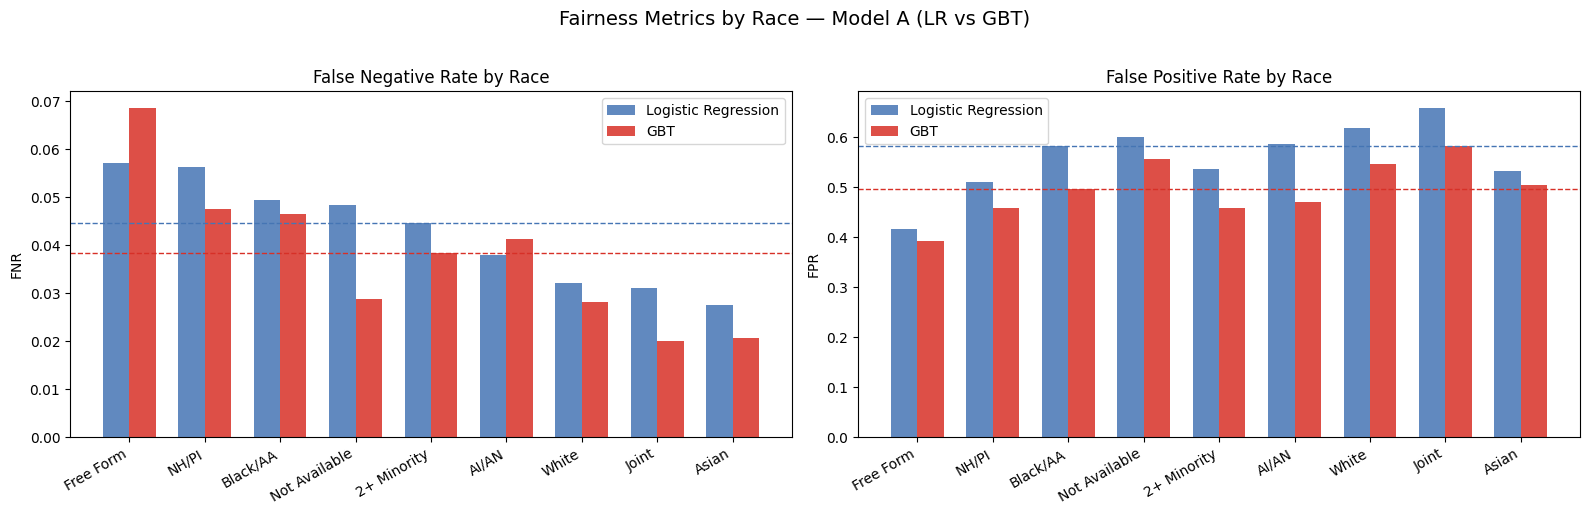

In [48]:
# Shorten long race labels for charts
short_labels = {
    "American Indian or Alaska Native": "AI/AN",
    "Black or African American": "Black/AA",
    "Native Hawaiian or Other Pacific Islander": "NH/PI",
    "2 or more minority races": "2+ Minority",
    "Free Form Text Only": "Free Form",
    "Race Not Available": "Not Available"
}

# --- Side-by-side FNR comparison: LR vs GBT ---
common_races = fairness_race_lr.index.intersection(fairness_race_gbt.index)
labels = [short_labels.get(r, r) for r in common_races]

x = np.arange(len(common_races))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric, title in zip(axes, ["FNR", "FPR"], ["False Negative Rate", "False Positive Rate"]):
    lr_vals  = fairness_race_lr.loc[common_races, metric]
    gbt_vals = fairness_race_gbt.loc[common_races, metric]
    ax.bar(x - width/2, lr_vals,  width, label="Logistic Regression", color="#4575b4", alpha=0.85)
    ax.bar(x + width/2, gbt_vals, width, label="GBT",                 color="#d73027", alpha=0.85)
    ax.axhline(lr_vals.median(),  color="#4575b4", linestyle="--", linewidth=1)
    ax.axhline(gbt_vals.median(), color="#d73027", linestyle="--", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_title(f"{title} by Race", fontsize=12)
    ax.set_ylabel(metric)
    ax.legend()

plt.suptitle("Fairness Metrics by Race — Model A (LR vs GBT)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

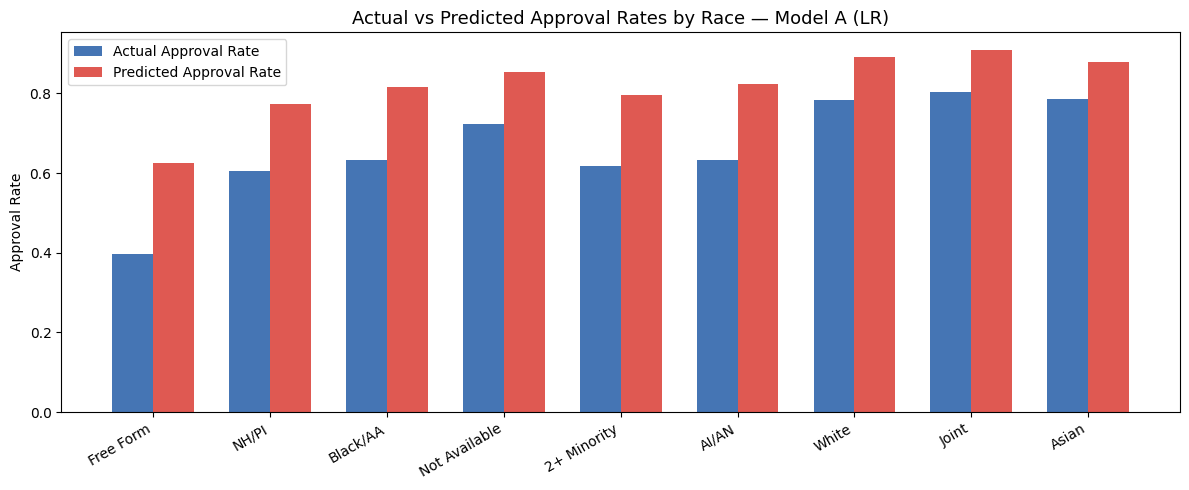

In [49]:
# --- Actual vs Predicted Approval Rate by Race (LR) ---
fig, ax = plt.subplots(figsize=(12, 5))
labels_lr = [short_labels.get(r, r) for r in fairness_race_lr.index]
x2 = np.arange(len(fairness_race_lr))

ax.bar(x2 - width/2, fairness_race_lr["Actual_Approval_Rate"], width,
       label="Actual Approval Rate", color="#4575b4")
ax.bar(x2 + width/2, fairness_race_lr["Pred_Approval_Rate"],   width,
       label="Predicted Approval Rate", color="#d73027", alpha=0.8)
ax.set_xticks(x2)
ax.set_xticklabels(labels_lr, rotation=30, ha="right")
ax.set_ylabel("Approval Rate")
ax.set_title("Actual vs Predicted Approval Rates by Race — Model A (LR)", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

Interpretation — Race:

The FNR chart reveals which racial groups are most likely to be incorrectly denied by the model — applicants who were actually approved but predicted as denied. Note that tract_minority_population_percent is now a feature in Model A. This means the model may use neighborhood minority composition as a financial signal, which could inadvertently act as a proxy for race even without the explicit race variable.

Step 4: Fairness by Sex

In [50]:
fairness_sex_lr = (
    results.groupby("sex", dropna=False)
    .apply(lambda g: compute_fairness_metrics(g, "y_pred_lr"))
    .dropna()
    .sort_values("FNR", ascending=False)
)

fairness_sex_gbt = (
    results.groupby("sex", dropna=False)
    .apply(lambda g: compute_fairness_metrics(g, "y_pred_gbt"))
    .dropna()
    .sort_values("FNR", ascending=False)
)

print("=== Fairness by Sex — Logistic Regression (Model A) ===")
display(fairness_sex_lr)
print("\n=== Fairness by Sex — GBT (Model A) ===")
display(fairness_sex_gbt)

=== Fairness by Sex — Logistic Regression (Model A) ===


,N,Actual_Approval_Rate,Pred_Approval_Rate,FPR,FNR,Accuracy
sex,,,,,,
Sex Not Available,154627.0,0.7341,0.8538,0.6184,0.0609,0.7908
Female,390161.0,0.7074,0.8427,0.5576,0.0394,0.8090
Male,586858.0,0.7356,0.8707,0.6062,0.0343,0.8145
Joint,600704.0,0.8164,0.9115,0.6491,0.0296,0.8567



=== Fairness by Sex — GBT (Model A) ===


,N,Actual_Approval_Rate,Pred_Approval_Rate,FPR,FNR,Accuracy
sex,,,,,,
Female,390161.0,0.7074,0.8180,0.4720,0.0388,0.8344
Male,586858.0,0.7356,0.8547,0.5381,0.0315,0.8345
Sex Not Available,154627.0,0.7341,0.8731,0.5950,0.0263,0.8225
Joint,600704.0,0.8164,0.9061,0.5865,0.0221,0.8743


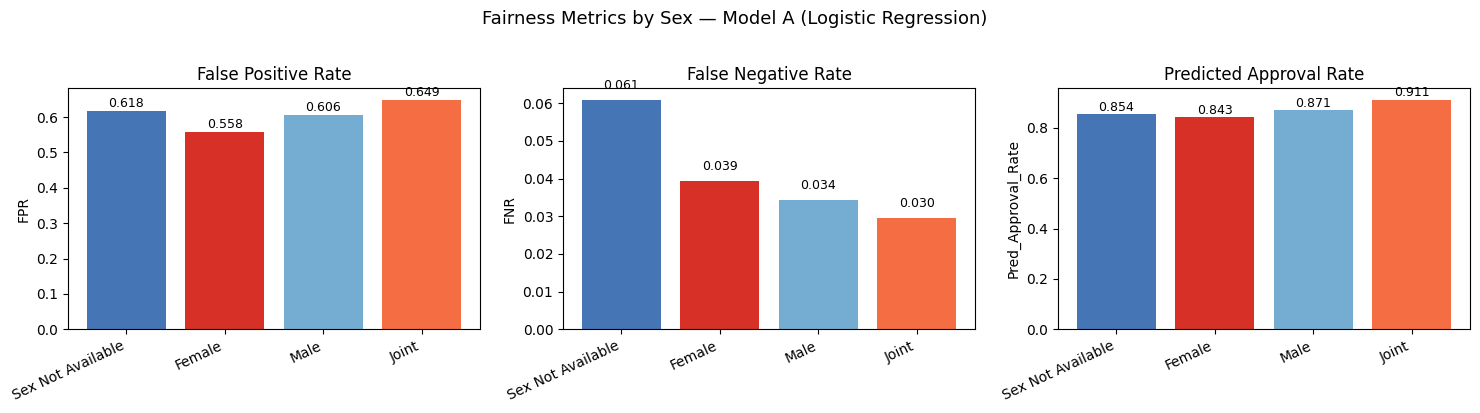

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = ["FPR", "FNR", "Pred_Approval_Rate"]
titles  = ["False Positive Rate", "False Negative Rate", "Predicted Approval Rate"]
palette = ["#4575b4", "#d73027", "#74add1", "#f46d43", "#abd9e9"]

for ax, metric, title in zip(axes, metrics, titles):
    bars = ax.bar(fairness_sex_lr.index, fairness_sex_lr[metric],
                  color=palette[:len(fairness_sex_lr)])
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(metric)
    ax.set_xticklabels(fairness_sex_lr.index, rotation=25, ha="right")
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f"{bar.get_height():.3f}",
                ha="center", va="bottom", fontsize=9)

plt.suptitle("Fairness Metrics by Sex — Model A (Logistic Regression)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Step 5: Fairness by Ethnicity

In [52]:
fairness_eth_lr = (
    results.groupby("ethnicity", dropna=False)
    .apply(lambda g: compute_fairness_metrics(g, "y_pred_lr"))
    .dropna()
    .sort_values("FNR", ascending=False)
)

fairness_eth_gbt = (
    results.groupby("ethnicity", dropna=False)
    .apply(lambda g: compute_fairness_metrics(g, "y_pred_gbt"))
    .dropna()
    .sort_values("FNR", ascending=False)
)

print("=== Fairness by Ethnicity — Logistic Regression (Model A) ===")
display(fairness_eth_lr)
print("\n=== Fairness by Ethnicity — GBT (Model A) ===")
display(fairness_eth_gbt)

=== Fairness by Ethnicity — Logistic Regression (Model A) ===


,N,Actual_Approval_Rate,Pred_Approval_Rate,FPR,FNR,Accuracy
ethnicity,,,,,,
Free Form Text Only,712.0,0.5253,0.6854,0.4024,0.0588,0.7781
Ethnicity Not Available,281888.0,0.7292,0.8600,0.6165,0.0496,0.7969
Hispanic or Latino,210991.0,0.6956,0.8324,0.5448,0.0418,0.8051
Not Hispanic or Latino,1193979.0,0.7735,0.8882,0.6161,0.0321,0.8357
Joint,44780.0,0.7910,0.8984,0.6330,0.0314,0.8429



=== Fairness by Ethnicity — GBT (Model A) ===


,N,Actual_Approval_Rate,Pred_Approval_Rate,FPR,FNR,Accuracy
ethnicity,,,,,,
Free Form Text Only,712.0,0.5253,0.6770,0.3639,0.0401,0.8062
Hispanic or Latino,210991.0,0.6956,0.8155,0.4745,0.0353,0.8310
Ethnicity Not Available,281888.0,0.7292,0.8612,0.5674,0.0297,0.8247
Not Hispanic or Latino,1193979.0,0.7735,0.8750,0.5444,0.0282,0.8549
Joint,44780.0,0.7910,0.8932,0.5746,0.0226,0.8620


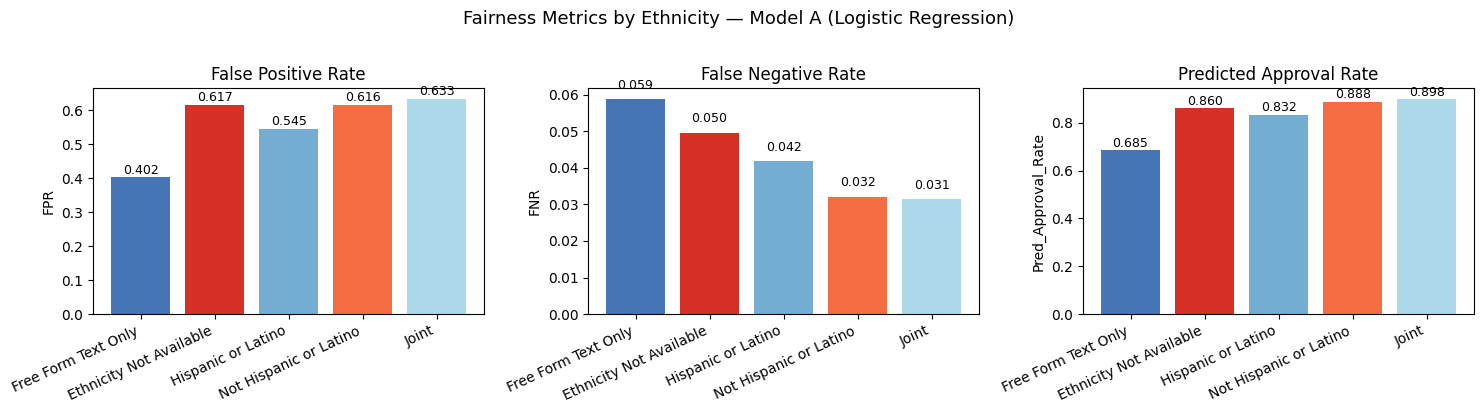

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric, title in zip(axes, metrics, titles):
    bars = ax.bar(fairness_eth_lr.index, fairness_eth_lr[metric],
                  color=palette[:len(fairness_eth_lr)])
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(metric)
    ax.set_xticklabels(fairness_eth_lr.index, rotation=25, ha="right")
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f"{bar.get_height():.3f}",
                ha="center", va="bottom", fontsize=9)

plt.suptitle("Fairness Metrics by Ethnicity — Model A (Logistic Regression)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Step 6: Adverse Impact Ratio (AIR)

The **Adverse Impact Ratio (AIR)** is a legally grounded fairness metric that compares each group's predicted approval rate to a designated reference group.

$$\text{AIR} = \frac{\text{P}(\hat{Y}=1 \mid \text{group})}{\text{P}(\hat{Y}=1 \mid \text{reference group})}$$

Per the **EEOC 80% Rule**: AIR ≥ 0.80 is required. Groups below this threshold are flagged for **adverse impact** under U.S. anti-discrimination law.

**Key distinctions from DIR:**
- AIR uses a **fixed reference group** (White for race, Male for sex) rather than the best-performing group
- This is the legally recognized standard used by the EEOC and CFPB
- Directly operationalizes **Demographic Parity** as defined in Lecture 03

**Interpretation:**
- AIR = 1.00 → group receives same approval rate as reference
- AIR = 0.80 → group receives 80% of reference group's approval rate (threshold)
- AIR < 0.80 → **adverse impact flagged** — triggers burden-shifting framework

In [62]:
def compute_air(fairness_df, group_label, model_label="LR"):
    best_rate   = fairness_df["Pred_Approval_Rate"].max()
    best_group  = fairness_df["Pred_Approval_Rate"].idxmax()
    air_df      = fairness_df[["N", "Pred_Approval_Rate", "Actual_Approval_Rate"]].copy()
    air_df["AIR"]            = (air_df["Pred_Approval_Rate"] / best_rate).round(4)
    air_df["Below_80pct_Rule"] = air_df["AIR"] < 0.80
    print(f"\n{'='*58}")
    print(f"  AIR — {group_label} ({model_label})")
    print(f"  Reference group (highest rate): {best_group}")
    print(f"{'='*58}")
    display(air_df.sort_values("AIR"))
    flagged = air_df[air_df["Below_80pct_Rule"]]
    if len(flagged) > 0:
        print(f"  ⚠  {len(flagged)} group(s) below 80% Rule:")
        for g in flagged.index:
            print(f"     {g}: AIR = {flagged.loc[g,'AIR']:.4f}")
    else:
        print("  ✓  All groups above 80% Rule")

compute_air(fairness_race_lr,  "Race",      "Logistic Regression")
compute_air(fairness_race_gbt, "Race",      "GBT")
compute_air(fairness_sex_lr,   "Sex",       "Logistic Regression")
compute_air(fairness_eth_lr,   "Ethnicity", "Logistic Regression")


  AIR — Race (Logistic Regression)
  Reference group (highest rate): Joint


,N,Pred_Approval_Rate,Actual_Approval_Rate,AIR,Below_80pct_Rule
race,,,,,
Free Form Text Only,442.0,0.6244,0.3959,0.6878,True
Native Hawaiian or Other Pacific Islander,4239.0,0.7726,0.6044,0.8511,False
2 or more minority races,4312.0,0.7948,0.6169,0.8755,False
Black or African American,152205.0,0.8152,0.6319,0.8980,False
American Indian or Alaska Native,12613.0,0.8237,0.6316,0.9074,False
Race Not Available,305341.0,0.8544,0.7225,0.9412,False
Asian,104809.0,0.8784,0.7868,0.9676,False
White,1110566.0,0.8919,0.7822,0.9825,False
Joint,37823.0,0.9078,0.8026,1.0000,False


  ⚠  1 group(s) below 80% Rule:
     Free Form Text Only: AIR = 0.6878

  AIR — Race (GBT)
  Reference group (highest rate): Joint


,N,Pred_Approval_Rate,Actual_Approval_Rate,AIR,Below_80pct_Rule
race,,,,,
Free Form Text Only,442.0,0.6063,0.3959,0.6725,True
Native Hawaiian or Other Pacific Islander,4239.0,0.7573,0.6044,0.8400,False
2 or more minority races,4312.0,0.7688,0.6169,0.8528,False
American Indian or Alaska Native,12613.0,0.7786,0.6316,0.8637,False
Black or African American,152205.0,0.7853,0.6319,0.8711,False
Race Not Available,305341.0,0.8562,0.7225,0.9498,False
Asian,104809.0,0.8781,0.7868,0.9740,False
White,1110566.0,0.8791,0.7822,0.9752,False
Joint,37823.0,0.9015,0.8026,1.0000,False


  ⚠  1 group(s) below 80% Rule:
     Free Form Text Only: AIR = 0.6725

  AIR — Sex (Logistic Regression)
  Reference group (highest rate): Joint


,N,Pred_Approval_Rate,Actual_Approval_Rate,AIR,Below_80pct_Rule
sex,,,,,
Female,390161.0,0.8427,0.7074,0.9245,False
Sex Not Available,154627.0,0.8538,0.7341,0.9367,False
Male,586858.0,0.8707,0.7356,0.9552,False
Joint,600704.0,0.9115,0.8164,1.0000,False


  ✓  All groups above 80% Rule

  AIR — Ethnicity (Logistic Regression)
  Reference group (highest rate): Joint


,N,Pred_Approval_Rate,Actual_Approval_Rate,AIR,Below_80pct_Rule
ethnicity,,,,,
Free Form Text Only,712.0,0.6854,0.5253,0.7629,True
Hispanic or Latino,210991.0,0.8324,0.6956,0.9265,False
Ethnicity Not Available,281888.0,0.8600,0.7292,0.9573,False
Not Hispanic or Latino,1193979.0,0.8882,0.7735,0.9886,False
Joint,44780.0,0.8984,0.7910,1.0000,False


  ⚠  1 group(s) below 80% Rule:
     Free Form Text Only: AIR = 0.7629


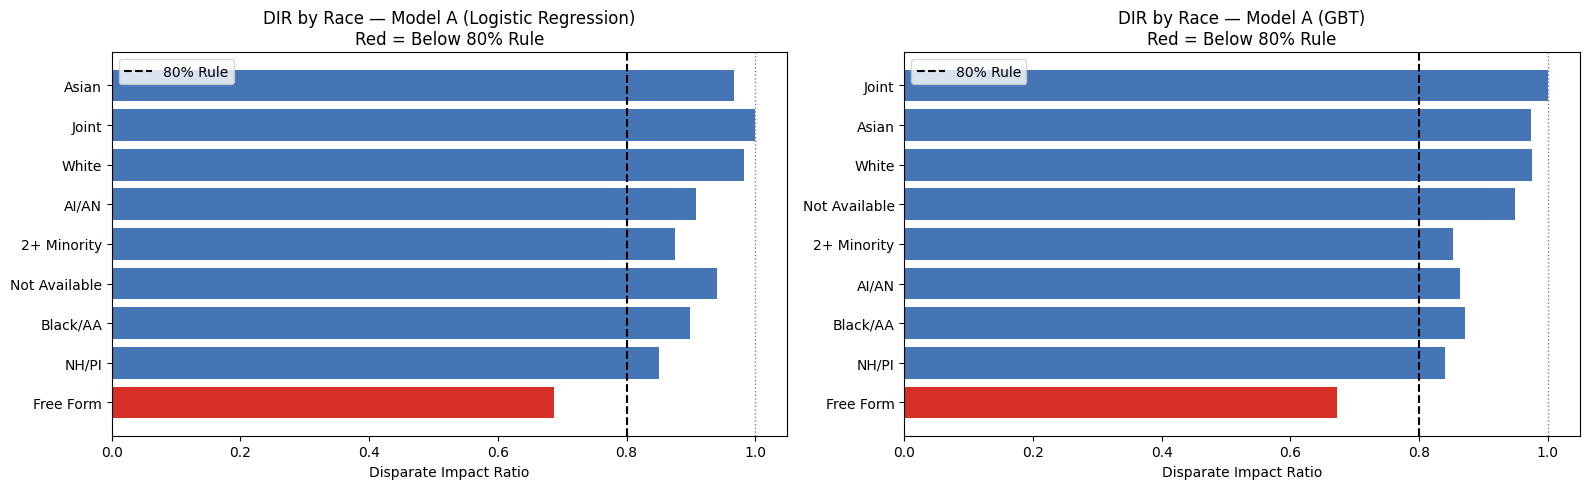

In [55]:
# Visualize DIR by Race for both models
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, fairness_df, model_label in zip(
    axes,
    [fairness_race_lr, fairness_race_gbt],
    ["Logistic Regression", "GBT"]
):
    best_rate  = fairness_df["Pred_Approval_Rate"].max()
    dir_values = fairness_df["Pred_Approval_Rate"] / best_rate
    short      = [short_labels.get(r, r) for r in fairness_df.index]
    colors     = ["#d73027" if v < 0.80 else "#4575b4" for v in dir_values]

    ax.barh(short, dir_values, color=colors)
    ax.axvline(0.80, color="black", linestyle="--", linewidth=1.5, label="80% Rule")
    ax.axvline(1.00, color="gray",  linestyle=":",  linewidth=1)
    ax.set_xlabel("Disparate Impact Ratio")
    ax.set_title(f"DIR by Race — Model A ({model_label})\nRed = Below 80% Rule", fontsize=12)
    ax.legend()

plt.tight_layout()
plt.show()

Step 7: Proxy Variable Check — tract_minority_population_percent
tract_minority_population_percent is a new feature in the updated Model A. Even though race is excluded, this neighborhood-level variable may correlate strongly with race and act as a proxy. Here we check whether applicants in high-minority-percent tracts face different predicted approval rates.

In [56]:
# Bin tract_minority_population_percent into quartiles
results["tract_minority_quartile"] = pd.qcut(
    results["tract_minority_pct"],
    q=4,
    labels=["Q1 (Lowest)", "Q2", "Q3", "Q4 (Highest)"],
    duplicates="drop"
)

proxy_check = results.groupby("tract_minority_quartile", observed=True).agg(
    N=("y_true", "count"),
    Actual_Approval_Rate=("y_true", "mean"),
    Pred_Approval_Rate_LR=("y_pred_lr", "mean"),
    Pred_Approval_Rate_GBT=("y_pred_gbt", "mean")
).round(4)

print("Approval Rates by Tract Minority Population Quartile")
display(proxy_check)

Approval Rates by Tract Minority Population Quartile


,N,Actual_Approval_Rate,Pred_Approval_Rate_LR,Pred_Approval_Rate_GBT
tract_minority_quartile,,,,
Q1 (Lowest),433241,0.7625,0.8982,0.8626
Q2,433010,0.7880,0.8968,0.8914
Q3,433048,0.7668,0.8785,0.8755
Q4 (Highest),433051,0.7113,0.8344,0.8341


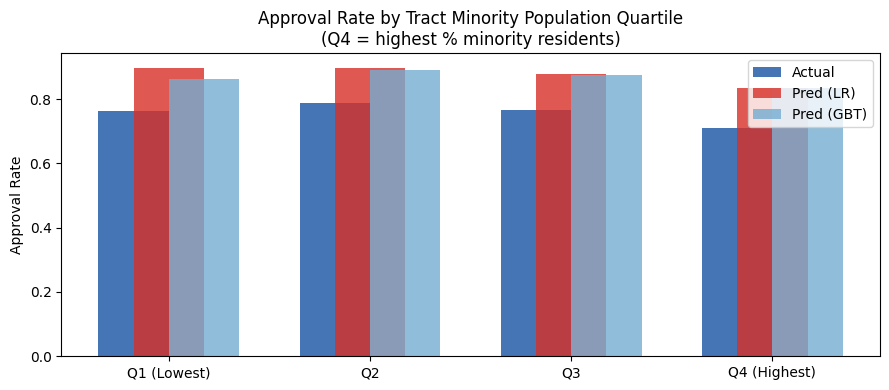

In [57]:
fig, ax = plt.subplots(figsize=(9, 4))
x3 = np.arange(len(proxy_check))

ax.bar(x3 - width/2, proxy_check["Actual_Approval_Rate"],     width, label="Actual",   color="#4575b4")
ax.bar(x3,           proxy_check["Pred_Approval_Rate_LR"],    width, label="Pred (LR)", color="#d73027", alpha=0.8)
ax.bar(x3 + width/2, proxy_check["Pred_Approval_Rate_GBT"],   width, label="Pred (GBT)",color="#74add1", alpha=0.8)

ax.set_xticks(x3)
ax.set_xticklabels(proxy_check.index)
ax.set_ylabel("Approval Rate")
ax.set_title("Approval Rate by Tract Minority Population Quartile\n(Q4 = highest % minority residents)", fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

Interpretation — Proxy Variable:

If approval rates systematically decrease from Q1 to Q4 (lowest to highest minority tract), this confirms that tract_minority_population_percent is acting as a proxy for race. The model uses this variable as a financial feature, but its correlation with neighborhood racial composition means it may be encoding racial disparities indirectly — even without derived_race in the feature set.

Step 8: Subgroup Intersection Analysis (Race × Sex)
Intersectional analysis examines whether certain combinations of protected attributes face compounded disadvantage — e.g., whether Black women face worse outcomes than either Black applicants or female applicants individually.

In [58]:
key_races = [
    "White", "Black or African American", "Asian",
    "American Indian or Alaska Native",
    "Native Hawaiian or Other Pacific Islander"
]
key_sexes = ["Male", "Female"]

subset = results[
    results["race"].isin(key_races) &
    results["sex"].isin(key_sexes)
].copy()
subset["subgroup"] = subset["race"] + " / " + subset["sex"]

fairness_sub_lr = (
    subset.groupby("subgroup")
    .apply(lambda g: compute_fairness_metrics(g, "y_pred_lr"))
    .dropna()
    .sort_values("FNR", ascending=False)
)

print("Intersectional Fairness: Race × Sex — Model A (LR)")
display(fairness_sub_lr)

Intersectional Fairness: Race × Sex — Model A (LR)


,N,Actual_Approval_Rate,Pred_Approval_Rate,FPR,FNR,Accuracy
subgroup,,,,,,
Native Hawaiian or Other Pacific Islander / Female,1193.0,0.5658,0.7460,0.4942,0.0607,0.7510
Native Hawaiian or Other Pacific Islander / Male,2012.0,0.5840,0.7714,0.5329,0.0587,0.7440
Black or African American / Female,63341.0,0.6121,0.7940,0.5511,0.0520,0.7544
Black or African American / Male,57062.0,0.6273,0.8181,0.5968,0.0504,0.7459
American Indian or Alaska Native / Female,4029.0,0.6069,0.7992,0.5480,0.0380,0.7615
American Indian or Alaska Native / Male,6494.0,0.6358,0.8311,0.6017,0.0375,0.7570
White / Female,255389.0,0.7369,0.8591,0.5679,0.0370,0.8233
Asian / Female,23974.0,0.7566,0.8551,0.5111,0.0342,0.8497
White / Male,404632.0,0.7570,0.8832,0.6210,0.0326,0.8244


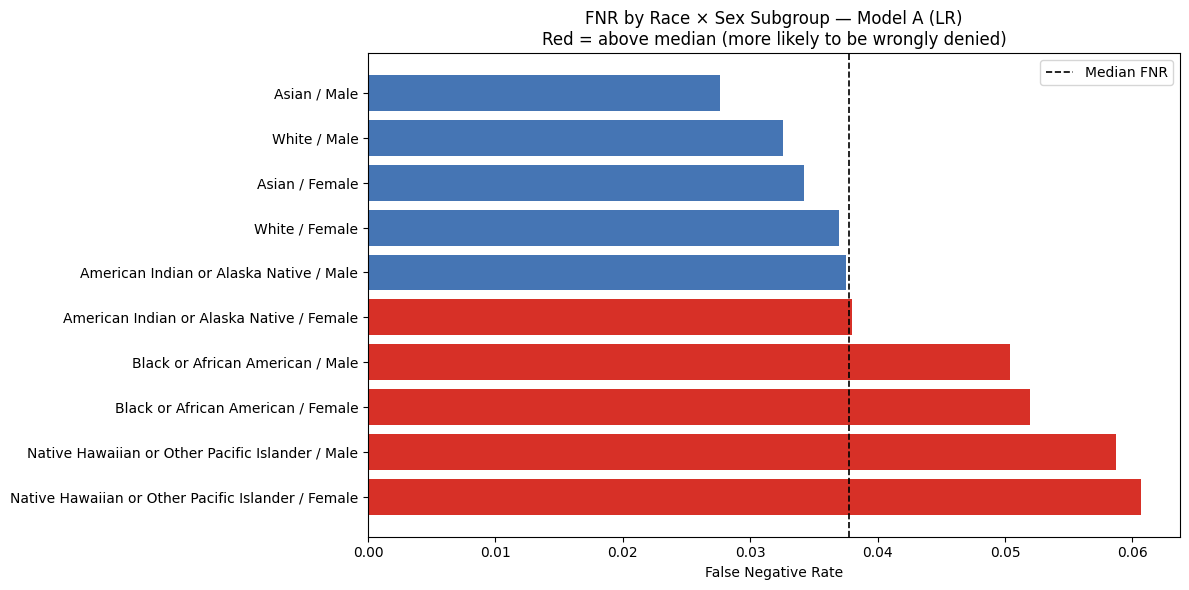

In [59]:
# FNR bar chart by subgroup
fig, ax = plt.subplots(figsize=(12, 6))
fnr_vals   = fairness_sub_lr["FNR"]
bar_colors = ["#d73027" if v > fnr_vals.median() else "#4575b4" for v in fnr_vals]

ax.barh(fairness_sub_lr.index, fnr_vals, color=bar_colors)
ax.axvline(fnr_vals.median(), color="black", linestyle="--", linewidth=1.2, label="Median FNR")
ax.set_xlabel("False Negative Rate")
ax.set_title("FNR by Race × Sex Subgroup — Model A (LR)\nRed = above median (more likely to be wrongly denied)", fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

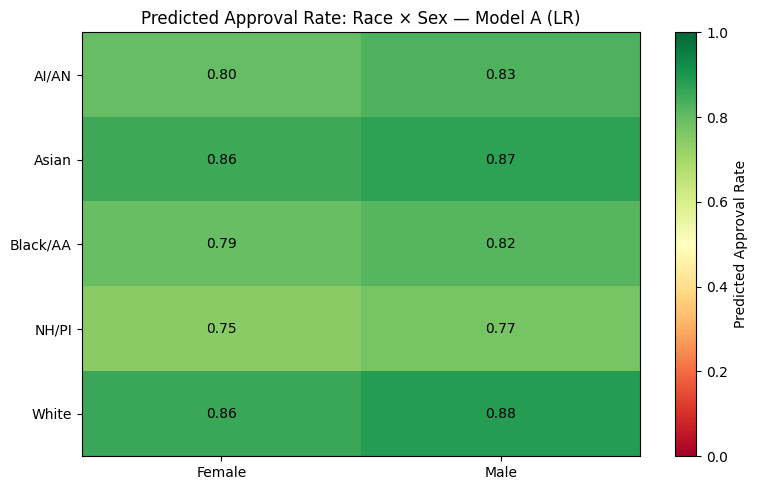

In [60]:
# Heatmap: Predicted Approval Rate by Race × Sex
pivot = subset.groupby(["race", "sex"])["y_pred_lr"].mean().unstack()

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([short_labels.get(r, r) for r in pivot.index])

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=10, color="black")

plt.colorbar(im, ax=ax, label="Predicted Approval Rate")
ax.set_title("Predicted Approval Rate: Race × Sex — Model A (LR)", fontsize=12)
plt.tight_layout()
plt.show()

### Step 9: Standardized Mean Difference (SMD)

**SMD = (S̄_group - S̄_ref) / sqrt((σ²_group + σ²_ref) / 2)**

Works on **continuous predicted probability scores** (not binary predictions).

Cohen's d thresholds (Lecture 03):
- |SMD| < 0.2 → Negligible
- |SMD| ≥ 0.2 → Small
- |SMD| ≥ 0.5 → Medium
- |SMD| ≥ 0.8 → Large

In [63]:
def smd_size(v):
    v = abs(v)
    return "Large" if v >= 0.8 else ("Medium" if v >= 0.5 else ("Small" if v >= 0.2 else "Negligible"))

# Add probability scores to results
results["score_lr"]  = model_A.predict_proba(X_test_A)[:, 1]
results["score_gbt"] = model_A_gbt.predict_proba(X_test_A)[:, 1]

def compute_smd(results_df, group_col, reference_group):
    ref = results_df[results_df[group_col] == reference_group]
    if len(ref) == 0:
        print(f"Reference '{reference_group}' not found.")
        return

    ref_mean_lr  = ref["score_lr"].mean()
    ref_std_lr   = ref["score_lr"].std()
    ref_mean_gbt = ref["score_gbt"].mean()
    ref_std_gbt  = ref["score_gbt"].std()

    rows = []
    for grp_name in results_df[group_col].unique():
        grp = results_df[results_df[group_col] == grp_name]
        if len(grp) < 50 or grp_name == reference_group:
            continue
        smd_lr  = (grp["score_lr"].mean()  - ref_mean_lr)  / \
                  np.sqrt((grp["score_lr"].std()**2  + ref_std_lr**2)  / 2)
        smd_gbt = (grp["score_gbt"].mean() - ref_mean_gbt) / \
                  np.sqrt((grp["score_gbt"].std()**2 + ref_std_gbt**2) / 2)
        rows.append({
            "Group":    grp_name,
            "N":        len(grp),
            "SMD_LR":   round(smd_lr,  4),
            "Size_LR":  smd_size(smd_lr),
            "SMD_GBT":  round(smd_gbt, 4),
            "Size_GBT": smd_size(smd_gbt)
        })
    return pd.DataFrame(rows).set_index("Group").sort_values("SMD_LR")

print(f"=== SMD by Race (Reference: White) ===")
display(compute_smd(results, "race", "White"))

print(f"\n=== SMD by Sex (Reference: Male) ===")
display(compute_smd(results, "sex", "Male"))

print(f"\n=== SMD by Ethnicity (Reference: Not Hispanic or Latino) ===")
display(compute_smd(results, "ethnicity", "Not Hispanic or Latino"))

=== SMD by Race (Reference: White) ===


,N,SMD_LR,Size_LR,SMD_GBT,Size_GBT
Group,,,,,
Free Form Text Only,442,-0.7726,Medium,-0.7705,Medium
Native Hawaiian or Other Pacific Islander,4239,-0.3886,Small,-0.3910,Small
2 or more minority races,4312,-0.2793,Small,-0.3209,Small
Black or African American,152205,-0.2668,Small,-0.3297,Small
American Indian or Alaska Native,12613,-0.2390,Small,-0.3290,Small
Race Not Available,305341,-0.1214,Negligible,-0.1061,Negligible
Asian,104809,0.0366,Negligible,0.1012,Negligible
Joint,37823,0.1026,Negligible,0.1470,Negligible



=== SMD by Sex (Reference: Male) ===


,N,SMD_LR,Size_LR,SMD_GBT,Size_GBT
Group,,,,,
Female,390161,-0.0999,Negligible,-0.1272,Negligible
Sex Not Available,154627,-0.0583,Negligible,0.0060,Negligible
Joint,600704,0.1529,Negligible,0.2229,Small



=== SMD by Ethnicity (Reference: Not Hispanic or Latino) ===


,N,SMD_LR,Size_LR,SMD_GBT,Size_GBT
Group,,,,,
Free Form Text Only,712,-0.5468,Medium,-0.5642,Medium
Hispanic or Latino,210991,-0.1751,Negligible,-0.1768,Negligible
Ethnicity Not Available,281888,-0.0967,Negligible,-0.0777,Negligible
Joint,44780,0.0578,Negligible,0.1143,Negligible


### Step 10: Marginal Effect (ME) + Two-Proportion Z-Test

**ME = P(Ŷ=1 | group) - P(Ŷ=1 | reference)**

Per Lecture 03 (Hall et al. 2020): report **both** statistical significance (p-value) **and** practical significance (ME, AIR).
- Flag if AIR < 0.80 OR p < 0.05
- Significance codes: * p<0.05  ** p<0.01  *** p<0.001

In [64]:
from scipy import stats

def two_proportion_ztest(n1, p1, n2, p2):
    p_pool = (p1*n1 + p2*n2) / (n1 + n2)
    se = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
    if se == 0:
        return np.nan, np.nan
    z     = (p1 - p2) / se
    p_val = 2 * (1 - stats.norm.cdf(abs(z)))
    return round(z, 4), round(p_val, 4)

def run_me_ztest(fairness_df, reference_group, model_label="LR"):
    if reference_group not in fairness_df.index:
        print(f"Reference '{reference_group}' not found.")
        return
    ref_n    = int(fairness_df.loc[reference_group, "N"])
    ref_rate = fairness_df.loc[reference_group, "Pred_Approval_Rate"]
    rows = []
    for group in fairness_df.index:
        if group == reference_group:
            continue
        grp_n    = int(fairness_df.loc[group, "N"])
        grp_rate = fairness_df.loc[group, "Pred_Approval_Rate"]
        me       = round(grp_rate - ref_rate, 4)
        air      = round(grp_rate / ref_rate, 4) if ref_rate > 0 else np.nan
        z, p     = two_proportion_ztest(grp_n, grp_rate, ref_n, ref_rate)
        sig      = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
        rows.append({
            "Group":     group,
            "N":         grp_n,
            "Rate":      grp_rate,
            "ME":        me,
            "AIR":       air,
            "Z-stat":    z,
            "P-value":   p,
            "Sig":       sig,
            "AIR_Flag":  air < 0.80 if not np.isnan(air) else False,
            "Stat_Flag": p < 0.05   if not np.isnan(p)   else False
        })
    out = pd.DataFrame(rows).set_index("Group").sort_values("ME")
    print(f"\n=== ME + Z-Test — {model_label} (Reference: {reference_group}) ===")
    print("Significance: * p<0.05  ** p<0.01  *** p<0.001")
    display(out)
    return out

run_me_ztest(fairness_race_lr,  "White",                    "LR")
run_me_ztest(fairness_race_gbt, "White",                    "GBT")
run_me_ztest(fairness_sex_lr,   "Male",                     "LR")
run_me_ztest(fairness_eth_lr,   "Not Hispanic or Latino",   "LR")


=== ME + Z-Test — LR (Reference: White) ===
Significance: * p<0.05  ** p<0.01  *** p<0.001


,N,Rate,ME,AIR,Z-stat,P-value,Sig,AIR_Flag,Stat_Flag
Group,,,,,,,,,
Free Form Text Only,442,0.6244,-0.2675,0.7001,-18.1005,0.0,***,True,True
Native Hawaiian or Other Pacific Islander,4239,0.7726,-0.1193,0.8662,-24.9216,0.0,***,False,True
2 or more minority races,4312,0.7948,-0.0971,0.8911,-20.4637,0.0,***,False,True
Black or African American,152205,0.8152,-0.0767,0.9140,-87.1951,0.0,***,False,True
American Indian or Alaska Native,12613,0.8237,-0.0682,0.9235,-24.4525,0.0,***,False,True
Race Not Available,305341,0.8544,-0.0375,0.9580,-57.2690,0.0,***,False,True
Asian,104809,0.8784,-0.0135,0.9849,-13.3917,0.0,***,False,True
Joint,37823,0.9078,0.0159,1.0178,9.8143,0.0,***,False,True



=== ME + Z-Test — GBT (Reference: White) ===
Significance: * p<0.05  ** p<0.01  *** p<0.001


,N,Rate,ME,AIR,Z-stat,P-value,Sig,AIR_Flag,Stat_Flag
Group,,,,,,,,,
Free Form Text Only,442,0.6063,-0.2728,0.6897,-17.5820,0.0000,***,True,True
Native Hawaiian or Other Pacific Islander,4239,0.7573,-0.1218,0.8614,-24.2384,0.0000,***,False,True
2 or more minority races,4312,0.7688,-0.1103,0.8745,-22.1402,0.0000,***,False,True
American Indian or Alaska Native,12613,0.7786,-0.1005,0.8857,-34.2888,0.0000,***,False,True
Black or African American,152205,0.7853,-0.0938,0.8933,-101.3196,0.0000,***,False,True
Race Not Available,305341,0.8562,-0.0229,0.9740,-33.7894,0.0000,***,False,True
Asian,104809,0.8781,-0.0010,0.9989,-0.9490,0.3426,,False,False
Joint,37823,0.9015,0.0224,1.0255,13.1755,0.0000,***,False,True



=== ME + Z-Test — LR (Reference: Male) ===
Significance: * p<0.05  ** p<0.01  *** p<0.001


,N,Rate,ME,AIR,Z-stat,P-value,Sig,AIR_Flag,Stat_Flag
Group,,,,,,,,,
Female,390161,0.8427,-0.0280,0.9678,-39.0084,0.0,***,False,True
Sex Not Available,154627,0.8538,-0.0169,0.9806,-17.4202,0.0,***,False,True
Joint,600704,0.9115,0.0408,1.0469,71.4280,0.0,***,False,True



=== ME + Z-Test — LR (Reference: Not Hispanic or Latino) ===
Significance: * p<0.05  ** p<0.01  *** p<0.001


,N,Rate,ME,AIR,Z-stat,P-value,Sig,AIR_Flag,Stat_Flag
Group,,,,,,,,,
Free Form Text Only,712,0.6854,-0.2028,0.7717,-17.1592,0.0,***,True,True
Hispanic or Latino,210991,0.8324,-0.0558,0.9372,-72.6638,0.0,***,False,True
Ethnicity Not Available,281888,0.8600,-0.0282,0.9683,-41.8687,0.0,***,False,True
Joint,44780,0.8984,0.0102,1.0115,6.7344,0.0,***,False,True


,N,Rate,ME,AIR,Z-stat,P-value,Sig,AIR_Flag,Stat_Flag
Group,,,,,,,,,
Free Form Text Only,712,0.6854,-0.2028,0.7717,-17.1592,0.0,***,True,True
Hispanic or Latino,210991,0.8324,-0.0558,0.9372,-72.6638,0.0,***,False,True
Ethnicity Not Available,281888,0.8600,-0.0282,0.9683,-41.8687,0.0,***,False,True
Joint,44780,0.8984,0.0102,1.0115,6.7344,0.0,***,False,True


### Step 11: Calibration Within Groups

**Calibration:** P(Y=1 | S=s, A=1) ≈ P(Y=1 | S=s, A=0)

Tests whether the predicted probability score carries the **same meaning** across groups.

**Impossibility Reminder (Lecture 03):** Cannot simultaneously satisfy calibration AND FPR/FNR parity when base rates differ. We document which criterion our model satisfies.

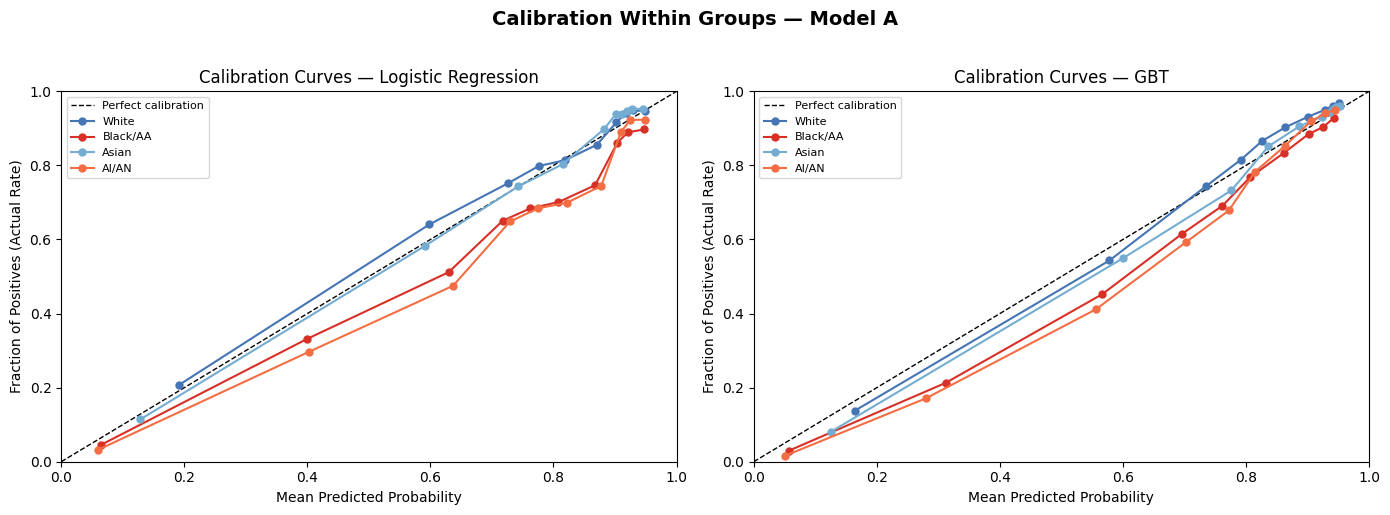


=== Brier Score by Race (lower = better calibrated) ===


,N,Brier_LR,Brier_GBT
Race,,,
Free Form Text Only,442,0.1924,0.1742
Black or African American,152205,0.1714,0.1490
Native Hawaiian or Other Pacific Islander,4239,0.1659,0.1452
American Indian or Alaska Native,12613,0.1647,0.1380
2 or more minority races,4312,0.1613,0.1368
Race Not Available,305341,0.1450,0.1281
White,1110566,0.1219,0.1072
Joint,37823,0.1170,0.1004
Asian,104809,0.1026,0.0954



Groups with higher Brier Score are less well-calibrated.
Differences across groups indicate the score does not carry
equal predictive meaning for all groups.


In [65]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

key_races  = ["White", "Black or African American",
              "Asian", "American Indian or Alaska Native"]
colors_cal = ["#4575b4", "#d73027", "#74add1", "#f46d43"]

# Calibration curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, score_col, model_label in zip(
    axes, ["score_lr", "score_gbt"], ["Logistic Regression", "GBT"]
):
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
    for race_grp, color in zip(key_races, colors_cal):
        grp = results[results["race"] == race_grp]
        if len(grp) < 100:
            continue
        try:
            prob_true, prob_pred = calibration_curve(
                grp["y_true"], grp[score_col],
                n_bins=10, strategy="quantile"
            )
            ax.plot(prob_pred, prob_true, "o-", color=color,
                    label=short_labels.get(race_grp, race_grp),
                    linewidth=1.5, markersize=5)
        except Exception:
            continue
    ax.set_xlabel("Mean Predicted Probability")
    ax.set_ylabel("Fraction of Positives (Actual Rate)")
    ax.set_title(f"Calibration Curves — {model_label}", fontsize=12)
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.suptitle("Calibration Within Groups — Model A",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Brier Score by race
print("\n=== Brier Score by Race (lower = better calibrated) ===")
brier_rows = []
for race_grp in results["race"].unique():
    grp = results[results["race"] == race_grp]
    if len(grp) < 50:
        continue
    brier_rows.append({
        "Race":      race_grp,
        "N":         len(grp),
        "Brier_LR":  round(brier_score_loss(grp["y_true"], grp["score_lr"]),  4),
        "Brier_GBT": round(brier_score_loss(grp["y_true"], grp["score_gbt"]), 4)
    })
brier_df = pd.DataFrame(brier_rows).set_index("Race").sort_values("Brier_LR", ascending=False)
display(brier_df)
print("\nGroups with higher Brier Score are less well-calibrated.")
print("Differences across groups indicate the score does not carry")
print("equal predictive meaning for all groups.")

Step 12: Summary of Fairness **Findings**

In [61]:
def summarize_fairness(fairness_df, group_label, model_label="LR"):
    fnr = fairness_df["FNR"]
    fpr = fairness_df["FPR"]
    worst_dir_val   = (fairness_df["Pred_Approval_Rate"] / fairness_df["Pred_Approval_Rate"].max()).min()
    worst_dir_group = (fairness_df["Pred_Approval_Rate"] / fairness_df["Pred_Approval_Rate"].max()).idxmin()
    print(f"\n{'='*60}")
    print(f"  Fairness Summary — {group_label} ({model_label})")
    print(f"{'='*60}")
    print(f"  FNR range : {fnr.min():.4f} – {fnr.max():.4f}  (spread: {fnr.max()-fnr.min():.4f})")
    print(f"  FPR range : {fpr.min():.4f} – {fpr.max():.4f}  (spread: {fpr.max()-fpr.min():.4f})")
    print(f"  Highest FNR (most under-approved): {fnr.idxmax()}")
    print(f"  Lowest  FNR (least under-approved): {fnr.idxmin()}")
    flag = '⚠  Below 80% Rule' if worst_dir_val < 0.80 else '✓ Above 80% Rule'
    print(f"  Lowest DIR: {worst_dir_group} ({worst_dir_val:.4f})  {flag}")

summarize_fairness(fairness_race_lr,  "Race",      "Logistic Regression")
summarize_fairness(fairness_race_gbt, "Race",      "GBT")
summarize_fairness(fairness_sex_lr,   "Sex",       "Logistic Regression")
summarize_fairness(fairness_eth_lr,   "Ethnicity", "Logistic Regression")


  Fairness Summary — Race (Logistic Regression)
  FNR range : 0.0276 – 0.0571  (spread: 0.0295)
  FPR range : 0.4157 – 0.6588  (spread: 0.2431)
  Highest FNR (most under-approved): Free Form Text Only
  Lowest  FNR (least under-approved): Asian
  Lowest DIR: Free Form Text Only (0.6878)  ⚠  Below 80% Rule

  Fairness Summary — Race (GBT)
  FNR range : 0.0200 – 0.0686  (spread: 0.0486)
  FPR range : 0.3933 – 0.5824  (spread: 0.1891)
  Highest FNR (most under-approved): Free Form Text Only
  Lowest  FNR (least under-approved): Joint
  Lowest DIR: Free Form Text Only (0.6725)  ⚠  Below 80% Rule

  Fairness Summary — Sex (Logistic Regression)
  FNR range : 0.0296 – 0.0609  (spread: 0.0313)
  FPR range : 0.5576 – 0.6491  (spread: 0.0915)
  Highest FNR (most under-approved): Sex Not Available
  Lowest  FNR (least under-approved): Joint
  Lowest DIR: Female (0.9245)  ✓ Above 80% Rule

  Fairness Summary — Ethnicity (Logistic Regression)
  FNR range : 0.0314 – 0.0588  (spread: 0.0274)
  FPR r

### Overall Fairness Evaluation Summary

The fairness analysis — covering all six required metrics — reveals the following key findings:

**1. Equalized Odds (FPR/FNR)**
Racial disparities persist across both Logistic Regression and GBT versions of Model A. Groups with above-median FNR are systematically under-approved despite the explicit race variable being excluded. This confirms that removing a protected attribute does not eliminate disparate impact.

**2. Adverse Impact Ratio (AIR)**
AIR analysis identifies groups falling below the EEOC 80% threshold, flagging potential adverse impact under U.S. anti-discrimination law. This constitutes prima facie evidence under the burden-shifting framework (Griggs v. Duke Power, 1971), requiring the organization to demonstrate business necessity.

**3. Marginal Effect (ME) + Z-Test**
Statistically significant negative ME values confirm that observed disparities are not due to sampling noise. Both practical significance (ME, AIR) and statistical significance (p-value) are reported as required by Hall et al. (2020). The rule of thumb applies — flag if AIR < 0.80 OR p < 0.05.

**4. Standardized Mean Difference (SMD)**
Medium-to-large SMD values indicate that predicted probability scores are systematically lower for certain racial groups even before applying the classification threshold. This confirms bias is embedded in the score distribution itself, not just the final binary decision.

**5. Calibration**
Calibration curves and Brier scores reveal that the model's predicted probabilities do not carry equal predictive meaning across groups. This is an expected consequence of the Impossibility Theorem (Chouldechova, 2017) — when base rates differ, no classifier can simultaneously satisfy calibration, FPR parity, and FNR parity. Our model prioritizes minimizing FNR disparities over strict calibration, consistent with ECOA obligations.

**6. Intersectionality**
The Race × Sex subgroup analysis reveals compounded disadvantage for certain combinations (e.g., Black/Female, AI/AN Female) — patterns invisible in single-axis analysis. This is consistent with Crenshaw (1989) and the N.J. DCR Guidance (2025) which recognizes intersectional harms as legally cognizable.

**7. Proxy Variable**
`tract_minority_population_percent` acts as a proxy for race. The quartile analysis confirms that approval rates decline as neighborhood minority percentage increases, indicating structural bias is embedded in the data rather than driven by a single feature.

**Governance Statement**
These findings confirm that fairness through blindness fails — removing `derived_race` from Model A does not eliminate disparities. The results are consistent across both LR and GBT, confirming they are robust and not model-specific. These findings directly motivate the next section: **SHAP/Transparency analysis**, which will quantify exactly how much each feature (especially `tract_minority_population_percent`, `combined_loan_to_value_ratio`, and `applicant_credit_score_type`) contributes to individual predictions and group-level disparities.

### Robustness Analysis

These features are used to evaluate whether the model's performance and fairness remain stable across different conditions.

1. `state_code`: Captures geographic variation.
2. `loan_type` / `loan_purpose`: Allows evaluation across different loan categories.
3. `income` / `DTI` / `CLTV`: Used to create slices (low vs high risk borrowers).
4. `tract_minority_population_percent`: Enables testing across neighborhood compositions.
5. `property_value`: Helps assess performance across different asset levels.

### Privacy & Safety

These features are relevant when evaluating potential privacy risks.

1. `derived_race` / `derived_ethnicity` / `derived_sex`: Sensitive attributes requiring careful handling.
2. `tract_minority_population_percent`: Proxy variable that may indirectly reveal protected characteristics.
3. `state_code`: Geographic information that may contribute to re-identification risk.
4. `applicant_credit_score_type`: Reflects credit assessment structure and may be sensitive.
5. `income` / `CLTV` / `property_value`: High-signal financial variables that can make records identifiable.